# IMPROVE-SPARTAN May Full Analysis

Goal: generate the graph set needed for the Ann/Warren/Sina task list.

This notebook starts from the existing cleaned IMPROVE FED pull and SPARTAN comparison outputs. It intentionally avoids arbitrary fAbs thresholds for the opening IMPROVE baseline, then adds Addis/ETAD loading/fAbs screens only as a second-stage comparability analysis.

Caveat for all R/T plots: the FED fields are labeled here as **FED laser R/T ratio fields**. They are not treated as raw Warren Figure 2 HIPS sphere/plate R/T signals because FED does not expose raw HIPS sphere/plate records, blanks, lot IDs, blank-line OLS coefficients, or batch metadata.

In [1]:
from __future__ import annotations

from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display, Image

ROOT = Path('../..').resolve()
FTIR = ROOT / 'research' / 'ftir_hips_chem'
IMPROVE = ROOT / 'research' / 'improve_hips_offset'
HIGH_FABS_OUT = FTIR / 'output' / 'improve_high_fabs_comparison'
MAY_PREP_OUT = IMPROVE / 'output' / 'warren_cena_improve_prep_analysis'
FIRST_ORDER_OUT = IMPROVE / 'output' / 'improve_first_order_loading_range_analysis'
ANALOG_OUT = IMPROVE / 'output' / 'improve_addis_analog_audit'
RT_PROXY_OUT = IMPROVE / 'output' / 'improve_fed_rt_proxy_figure2'
OUT = IMPROVE / 'output' / 'improve_spartan_may_full_analysis'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

SITE_COLORS = {
    'Beijing': '#4C78A8',
    'Delhi': '#F58518',
    'JPL': '#54A24B',
    'Addis_Ababa': '#E45756',
    'CHTS': '#4C78A8',
    'INDH': '#F58518',
    'USPA': '#54A24B',
    'ETAD': '#E45756',
}

FIGURES = []


def savefig(fig, name, caption):
    path = OUT / name
    fig.savefig(path, dpi=180, bbox_inches='tight')
    FIGURES.append({'figure': name, 'path': str(path.relative_to(ROOT)), 'caption': caption})
    plt.close(fig)
    return path


def read_csv(path, **kwargs):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

print(f'Output folder: {OUT.relative_to(ROOT)}')

Output folder: research/improve_hips_offset/output/improve_spartan_may_full_analysis


## 1. Load Existing Cleaned Outputs

The core IMPROVE table is already restricted to the current local FED pull used by `improve_high_fabs_comparison.ipynb`. It spans 2003-forward in the current export, so it is the working post-recalibration dataset until Warren confirms the exact cutoff.

In [2]:
improve_cols = [
    'Dataset', 'SiteCode', 'POC', 'Date', 'AuxID', 'ECf_Val', 'OCf_Val', 'fAbs_Val',
    'FlowRate_Val', 'SampDur_Val', 'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary',
    'fAbs_per_EC', 'OC_EC', 'FE_EC', 'SOIL_EC', 'MF_EC', 'year', 'month', 'SiteName',
    'Country', 'State', 'Latitude', 'Longitude', 'RefF_635_Val', 'TransF_635_Val',
    'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val', 'rt_available',
]
improve = read_csv(HIGH_FABS_OUT / 'improve_valid_cleaned.csv', usecols=lambda c: c in improve_cols, low_memory=False)
improve['Date'] = pd.to_datetime(improve['Date'])
improve = improve[(improve['ECf_Val'] > 0) & (improve['fAbs_Val'] > 0)].copy()
improve_loading = improve[improve['EC_loading_ug_cm2_primary'].notna()].copy()

spartan_loading = read_csv(HIGH_FABS_OUT / 'spartan_site_loading_summary.csv')
etad_bounds = read_csv(FIRST_ORDER_OUT / 'etad_reference_bounds.csv')
axis_counts = read_csv(MAY_PREP_OUT / 'improve_etad_axis_overlap_counts.csv')
waterfall = read_csv(FIRST_ORDER_OUT / 'screening_waterfall_p05p95.csv')
fits = read_csv(HIGH_FABS_OUT / 'improve_fabs_ec_fit_summary.csv')
bounded_fits = read_csv(MAY_PREP_OUT / 'improve_bounded_group_fits.csv')
comparable = read_csv(MAY_PREP_OUT / 'improve_first_order_comparable_rows.csv')
comparable['Date'] = pd.to_datetime(comparable['Date'])

summary = pd.DataFrame([
    {'dataset': 'IMPROVE valid EC + fAbs', 'n': len(improve), 'date_min': improve['Date'].min().date(), 'date_max': improve['Date'].max().date(), 'sites': improve['SiteCode'].nunique()},
    {'dataset': 'IMPROVE with EC loading', 'n': len(improve_loading), 'date_min': improve_loading['Date'].min().date(), 'date_max': improve_loading['Date'].max().date(), 'sites': improve_loading['SiteCode'].nunique()},
    {'dataset': 'IMPROVE first-order Addis/ETAD comparable', 'n': len(comparable), 'date_min': comparable['Date'].min().date(), 'date_max': comparable['Date'].max().date(), 'sites': comparable['SiteCode'].nunique()},
])
display(summary)
display(etad_bounds)

,dataset,n,date_min,date_max,sites
0,IMPROVE valid EC + fAbs,379697,2003-01-03,2025-07-30,214
1,IMPROVE with EC loading,152029,2015-08-01,2025-07-30,177
2,IMPROVE first-order Addis/ETAD comparable,10,2016-01-01,2025-01-01,7


,metric,n,min,p05,p25,median,p75,p95,max
0,fAbs_Mm-1,190,28.085699,34.680930,41.281968,47.132129,55.707245,68.043457,85.852735
1,EC_ug_m3,190,0.693115,2.364730,3.295147,4.624584,6.638418,9.600472,11.735113
2,EC_loading_ug_filter,190,4.870656,16.679911,23.874623,33.503921,47.618633,69.329343,82.464986
3,EC_loading_ug_cm2,190,1.379789,4.725187,6.763349,9.491196,13.489698,19.640041,23.361186


## 2. Post-2003 IMPROVE Baseline: Raw Scatter and Density

These two figures answer the first IMPROVE task directly: no arbitrary fAbs thresholds, just the post-2003 valid EC/fAbs dataset.

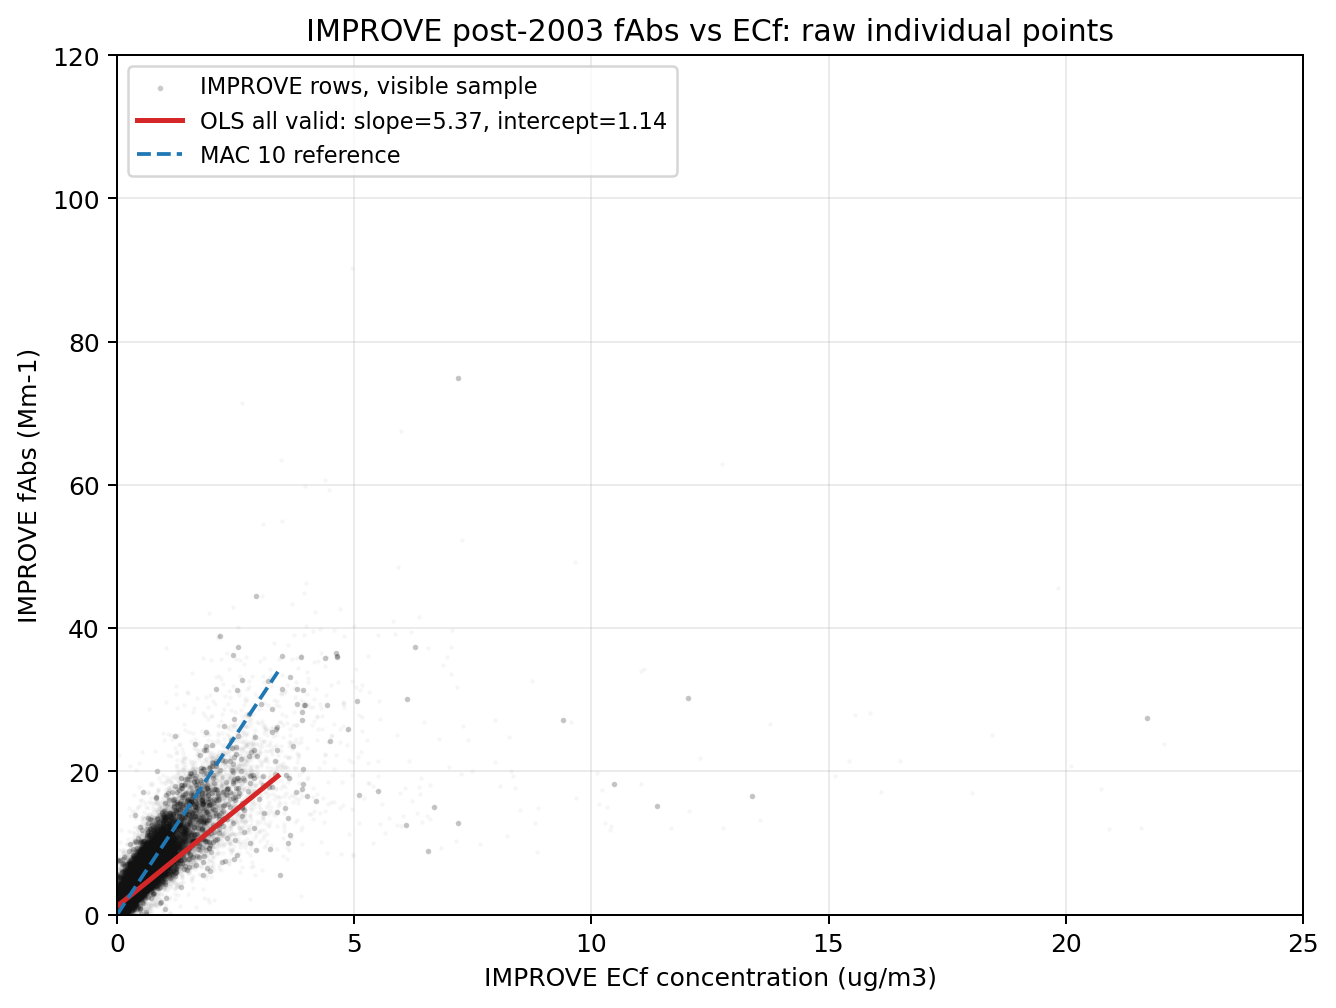

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
# Draw all rows faintly, then redraw a deterministic subset darker so individual points remain visible in notebooks/slides.
ax.scatter(improve['ECf_Val'], improve['fAbs_Val'], s=3, alpha=0.035, color='#111111', linewidths=0, rasterized=True)
visible_points = improve.sample(min(len(improve), 45000), random_state=7)
ax.scatter(visible_points['ECf_Val'], visible_points['fAbs_Val'], s=5, alpha=0.22, color='#111111', linewidths=0, rasterized=True, label='IMPROVE rows, visible sample')
# Fit the display range, not a screened subset.
plot_df = improve[['ECf_Val', 'fAbs_Val']].dropna()
slope, intercept = np.polyfit(plot_df['ECf_Val'], plot_df['fAbs_Val'], 1)
x = np.linspace(0, min(25, plot_df['ECf_Val'].quantile(0.999)), 200)
ax.plot(x, slope * x + intercept, color='#D62728', lw=2, label=f'OLS all valid: slope={slope:.2f}, intercept={intercept:.2f}')
ax.plot(x, 10 * x, color='#1F77B4', lw=1.5, ls='--', label='MAC 10 reference')
ax.set_xlim(0, 25)
ax.set_ylim(0, 120)
ax.set_xlabel('IMPROVE ECf concentration (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm-1)')
ax.set_title('IMPROVE post-2003 fAbs vs ECf: raw individual points')
ax.legend(loc='upper left', frameon=True)
caption = 'Raw post-2003 IMPROVE fAbs vs ECf baseline without arbitrary fAbs thresholding; all rows are drawn faintly with a darker deterministic visible sample.'
path = savefig(fig, 'fig01_improve_post2003_raw_fabs_vs_ec.png', caption)
Image(filename=str(path))

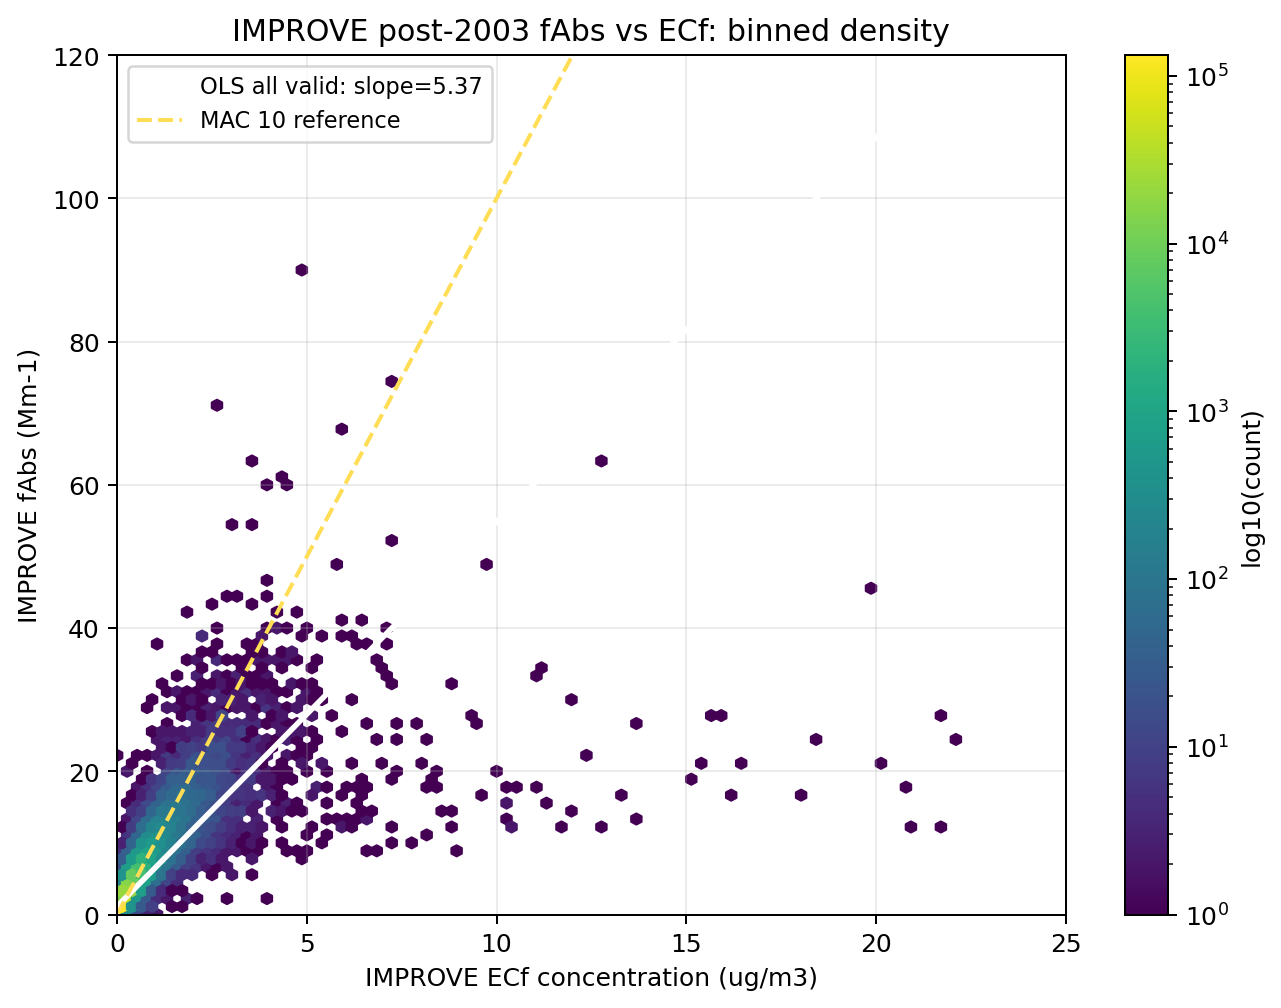

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
h = ax.hexbin(
    improve['ECf_Val'], improve['fAbs_Val'],
    gridsize=95, extent=(0, 25, 0, 120), mincnt=1, bins='log', cmap='viridis'
)
cb = fig.colorbar(h, ax=ax)
cb.set_label('log10(count)')
x = np.linspace(0, 25, 200)
ax.plot(x, slope * x + intercept, color='white', lw=2.2, label=f'OLS all valid: slope={slope:.2f}')
ax.plot(x, 10 * x, color='#FFDD55', lw=1.6, ls='--', label='MAC 10 reference')
ax.set_xlim(0, 25)
ax.set_ylim(0, 120)
ax.set_xlabel('IMPROVE ECf concentration (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm-1)')
ax.set_title('IMPROVE post-2003 fAbs vs ECf: binned density')
ax.legend(loc='upper left', frameon=True)
caption = 'Density view of the same unfiltered post-2003 IMPROVE baseline.'
path = savefig(fig, 'fig02_improve_post2003_density_fabs_vs_ec.png', caption)
Image(filename=str(path))

## 3. Convert to Mass Loading and Compare with SPARTAN/Addis

Mass loading is the filter-relevant axis. The graph below places the IMPROVE loading distribution against the SPARTAN site loading ranges, with Addis/ETAD emphasized.

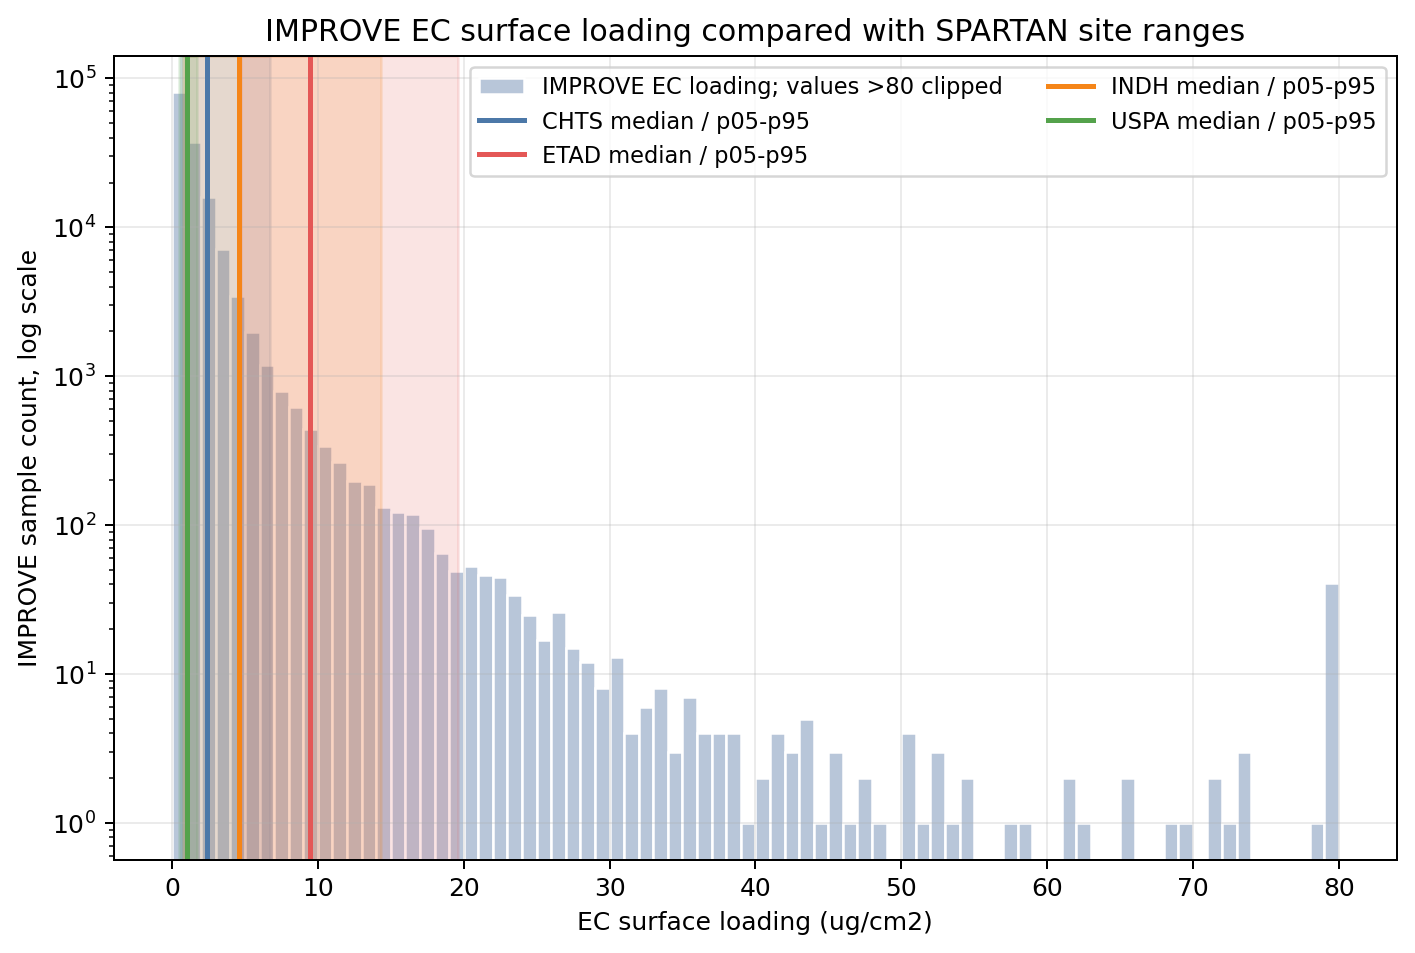

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 5.8))
loading = improve_loading['EC_loading_ug_cm2_primary'].dropna()
loading = loading[(loading > 0) & np.isfinite(loading)]
ax.hist(loading.clip(upper=80), bins=np.linspace(0, 80, 81), color='#B8C6D9', edgecolor='white', label='IMPROVE EC loading; values >80 clipped')
for _, row in spartan_loading.iterrows():
    site = row['Site']
    color = SITE_COLORS.get(site, '#333333')
    ax.axvspan(row['EC_loading_ug_cm2_p05'], row['EC_loading_ug_cm2_p95'], alpha=0.16, color=color)
    ax.axvline(row['EC_loading_ug_cm2_median'], color=color, lw=2, label=f'{site} median / p05-p95')
ax.set_yscale('log')
ax.set_xlabel('EC surface loading (ug/cm2)')
ax.set_ylabel('IMPROVE sample count, log scale')
ax.set_title('IMPROVE EC surface loading compared with SPARTAN site ranges')
ax.legend(loc='upper right', ncols=2, frameon=True)
caption = 'Filter-loading comparison: IMPROVE concentration is converted to EC surface loading and compared with SPARTAN p05-p95 ranges.'
path = savefig(fig, 'fig03_improve_loading_vs_spartan_ranges.png', caption)
Image(filename=str(path))

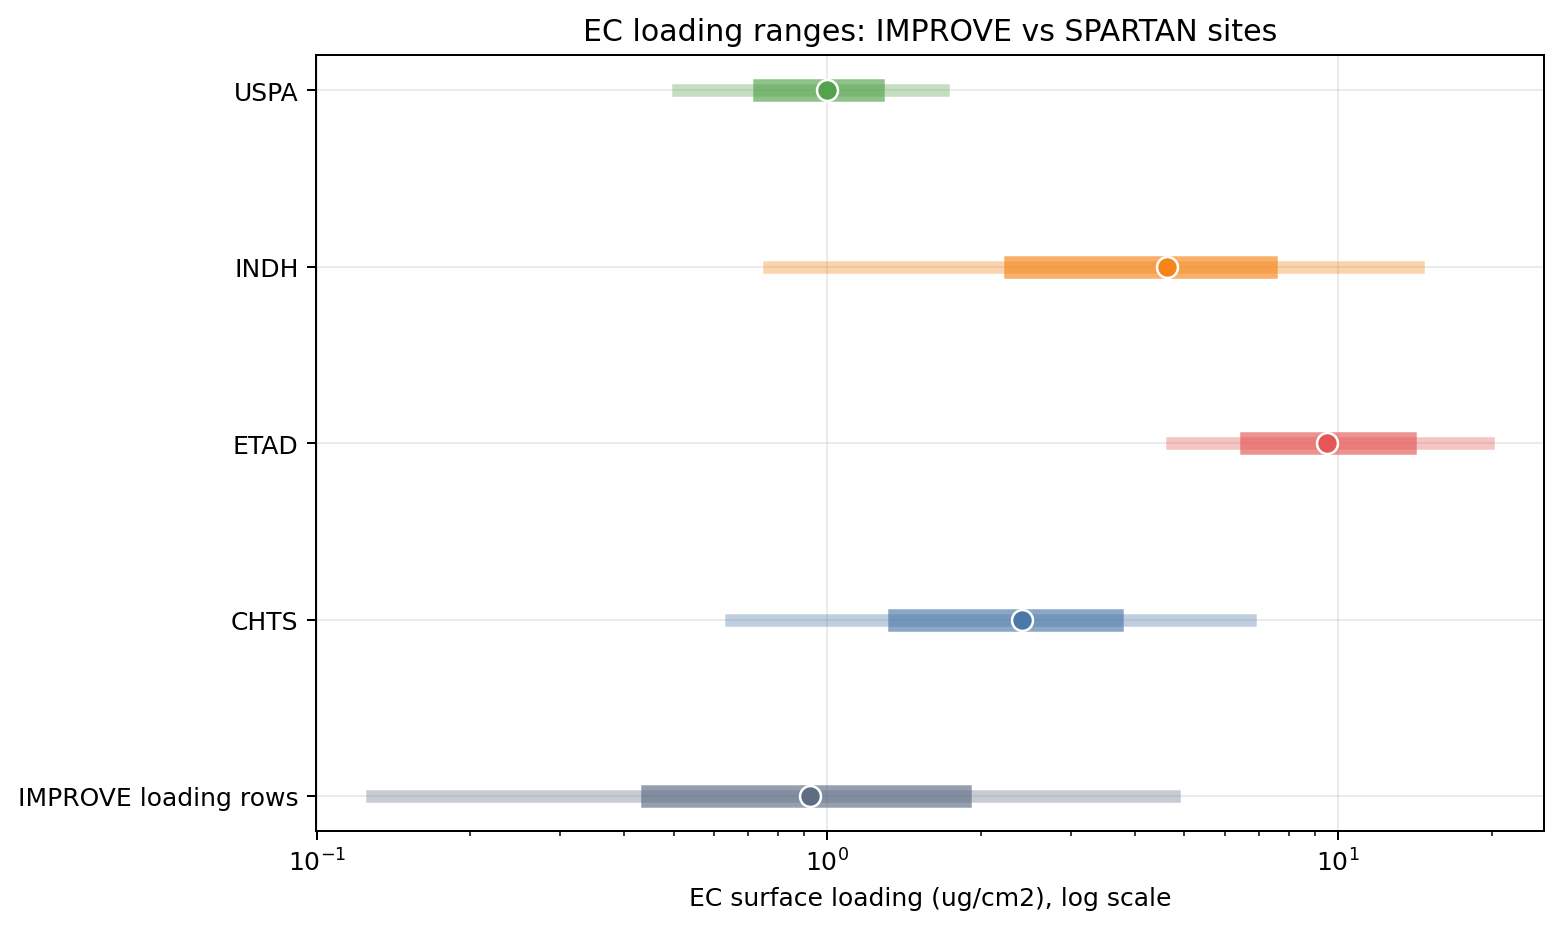

In [6]:
fig, ax = plt.subplots(figsize=(8.8, 5.6))
plot_rows = []
q = loading.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
plot_rows.append({'dataset': 'IMPROVE loading rows', 'p05': q.loc[0.05], 'p25': q.loc[0.25], 'median': q.loc[0.5], 'p75': q.loc[0.75], 'p95': q.loc[0.95]})
for _, row in spartan_loading.iterrows():
    plot_rows.append({'dataset': row['Site'], 'p05': row['EC_loading_ug_cm2_p05'], 'p25': row['EC_loading_ug_cm2_p25'], 'median': row['EC_loading_ug_cm2_median'], 'p75': row['EC_loading_ug_cm2_p75'], 'p95': row['EC_loading_ug_cm2_p95']})
range_df = pd.DataFrame(plot_rows)
y = np.arange(len(range_df))
for i, row in range_df.iterrows():
    color = SITE_COLORS.get(row['dataset'], '#5E6C84')
    ax.plot([row['p05'], row['p95']], [i, i], color=color, lw=5, alpha=0.35)
    ax.plot([row['p25'], row['p75']], [i, i], color=color, lw=9, alpha=0.65)
    ax.scatter(row['median'], i, color=color, s=70, zorder=3, edgecolor='white')
ax.set_yticks(y, range_df['dataset'])
ax.set_xscale('log')
ax.set_xlabel('EC surface loading (ug/cm2), log scale')
ax.set_title('EC loading ranges: IMPROVE vs SPARTAN sites')
caption = 'Range plot summarizing p05-p95, p25-p75, and median EC surface loading for IMPROVE and SPARTAN sites.'
path = savefig(fig, 'fig04_loading_range_summary.png', caption)
range_df.to_csv(OUT / 'loading_range_summary.csv', index=False)
Image(filename=str(path))

## 4. Axis-by-Axis Addis/ETAD Comparability Screens

This is the reframing requested in the task list: ask whether IMPROVE contains samples in the Addis/ETAD loading/fAbs regime before interpreting any MAC claim.

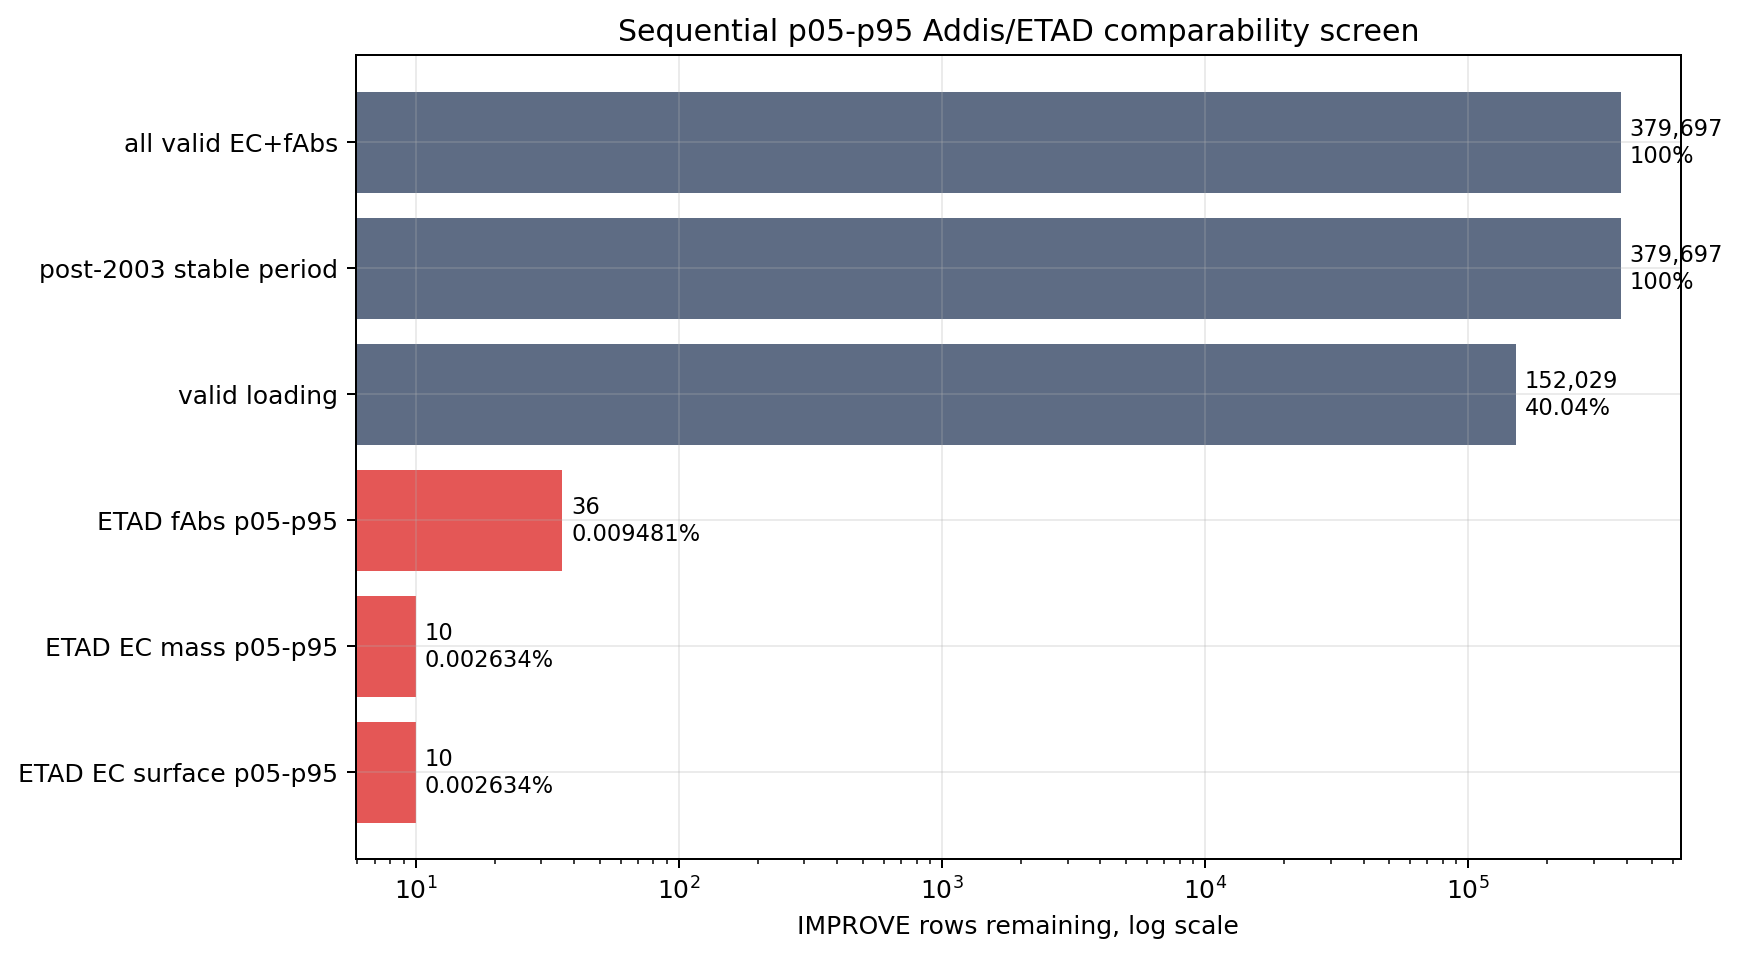

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
wf = waterfall.copy()
labels = wf['step'].str.replace('cleaned positive EC + fAbs, all years', 'all valid EC+fAbs').str.replace('valid EC mass/surface loading', 'valid loading')
colors = ['#5E6C84', '#5E6C84', '#5E6C84', '#E45756', '#E45756', '#E45756']
ax.barh(np.arange(len(wf)), wf['n'], color=colors[:len(wf)])
for i, row in wf.iterrows():
    ax.text(row['n'] * 1.08, i, f"{int(row['n']):,}\n{row['pct_initial']:.4g}%", va='center', fontsize=9)
ax.set_yticks(np.arange(len(wf)), labels)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlabel('IMPROVE rows remaining, log scale')
ax.set_title('Sequential p05-p95 Addis/ETAD comparability screen')
caption = 'Sequential screen showing how rare Addis/ETAD-like fAbs and EC loading overlap is in IMPROVE.'
path = savefig(fig, 'fig05_axis_by_axis_screening_waterfall.png', caption)
Image(filename=str(path))

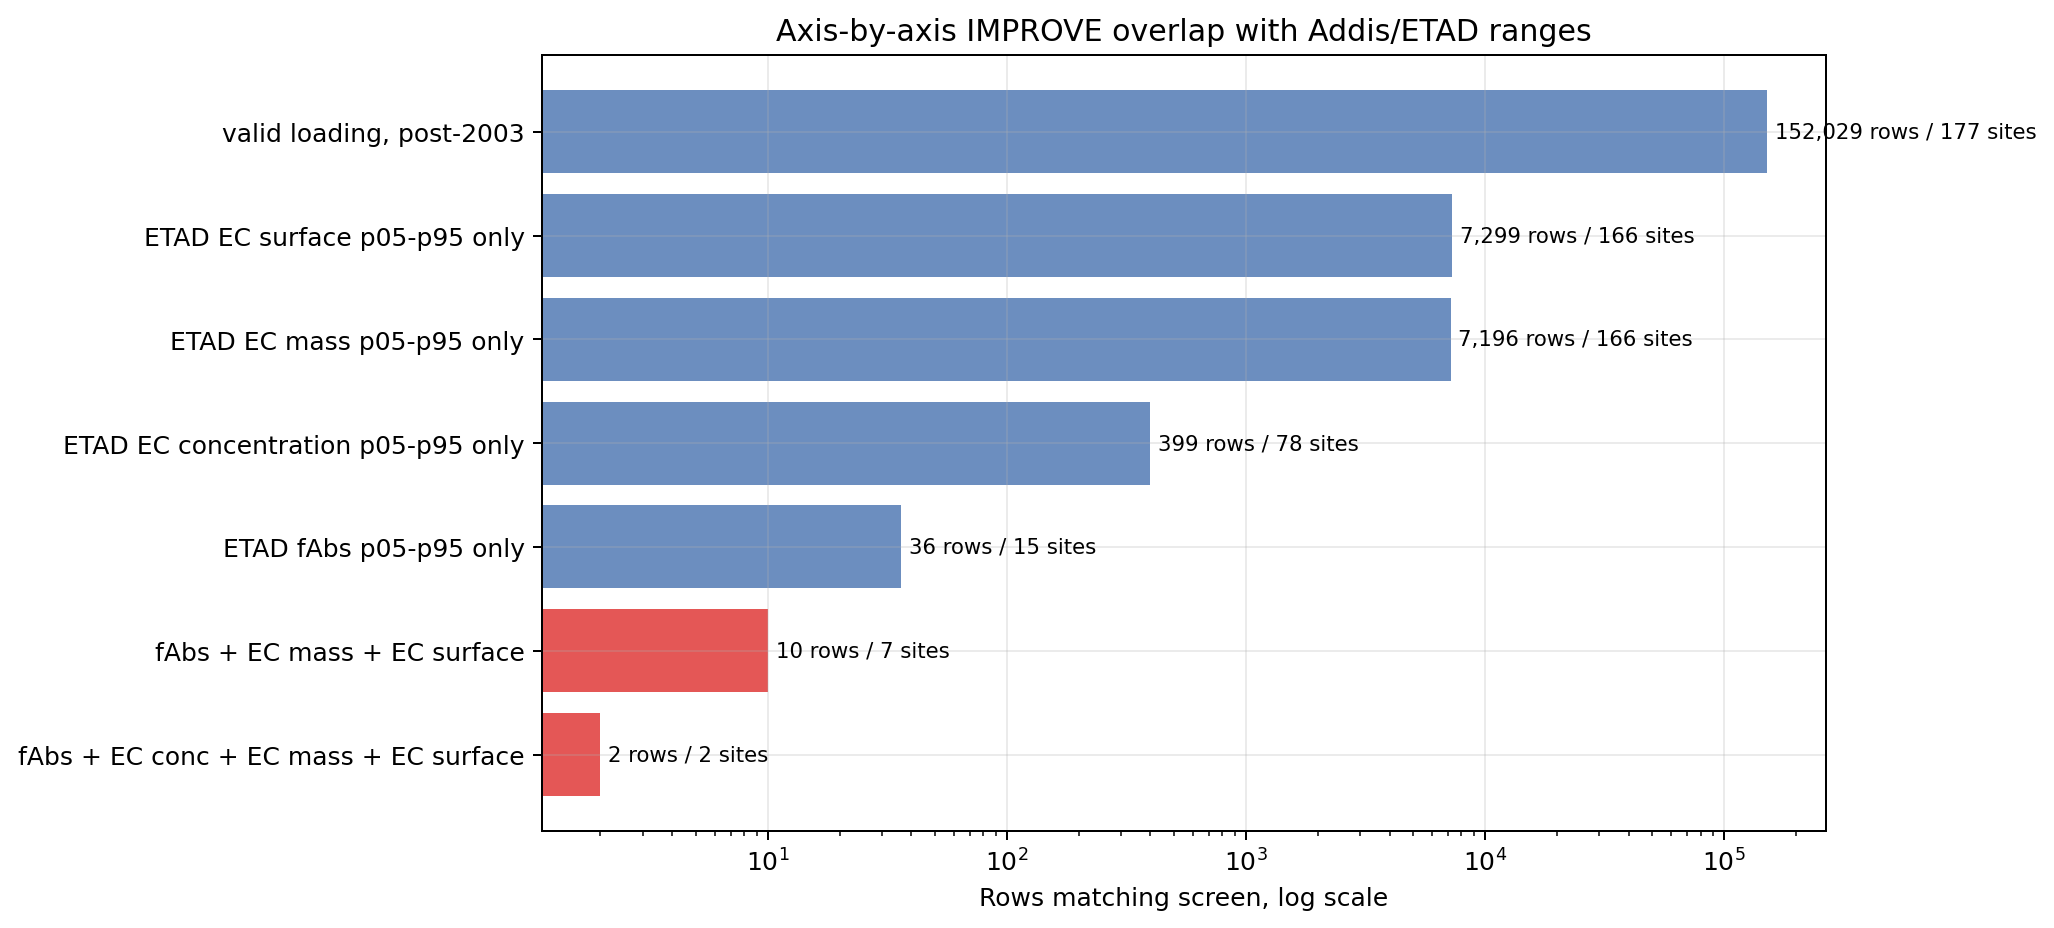

In [8]:
fig, ax = plt.subplots(figsize=(9.2, 5.6))
ac = axis_counts.copy().sort_values('n', ascending=True)
bar_colors = ['#E45756' if 'fAbs +' in s else '#6C8EBF' for s in ac['screen']]
ax.barh(ac['screen'], ac['n'], color=bar_colors)
for i, row in ac.reset_index(drop=True).iterrows():
    ax.text(row['n'] * 1.08, i, f"{int(row['n']):,} rows / {int(row['sites'])} sites", va='center', fontsize=8.5)
ax.set_xscale('log')
ax.set_xlabel('Rows matching screen, log scale')
ax.set_title('Axis-by-axis IMPROVE overlap with Addis/ETAD ranges')
caption = 'Independent axis overlap counts: fAbs, EC concentration, EC mass, EC surface loading, and combined screens.'
path = savefig(fig, 'fig06_axis_overlap_counts.png', caption)
Image(filename=str(path))

## 5. Which IMPROVE Rows Are in the ETAD EC Range?

This answers the narrow EC-range question separately from the stricter all-axis screen. Many IMPROVE rows have ETAD-like EC loading, but far fewer also have ETAD-like fAbs.

,screen,n,sites
0,ETAD EC concentration p05-p95,399,78
1,ETAD EC mass p05-p95,7196,166
2,ETAD EC surface loading p05-p95,7299,166
3,ETAD EC mass + surface p05-p95,7189,166
4,ETAD fAbs + EC mass + surface p05-p95,10,7


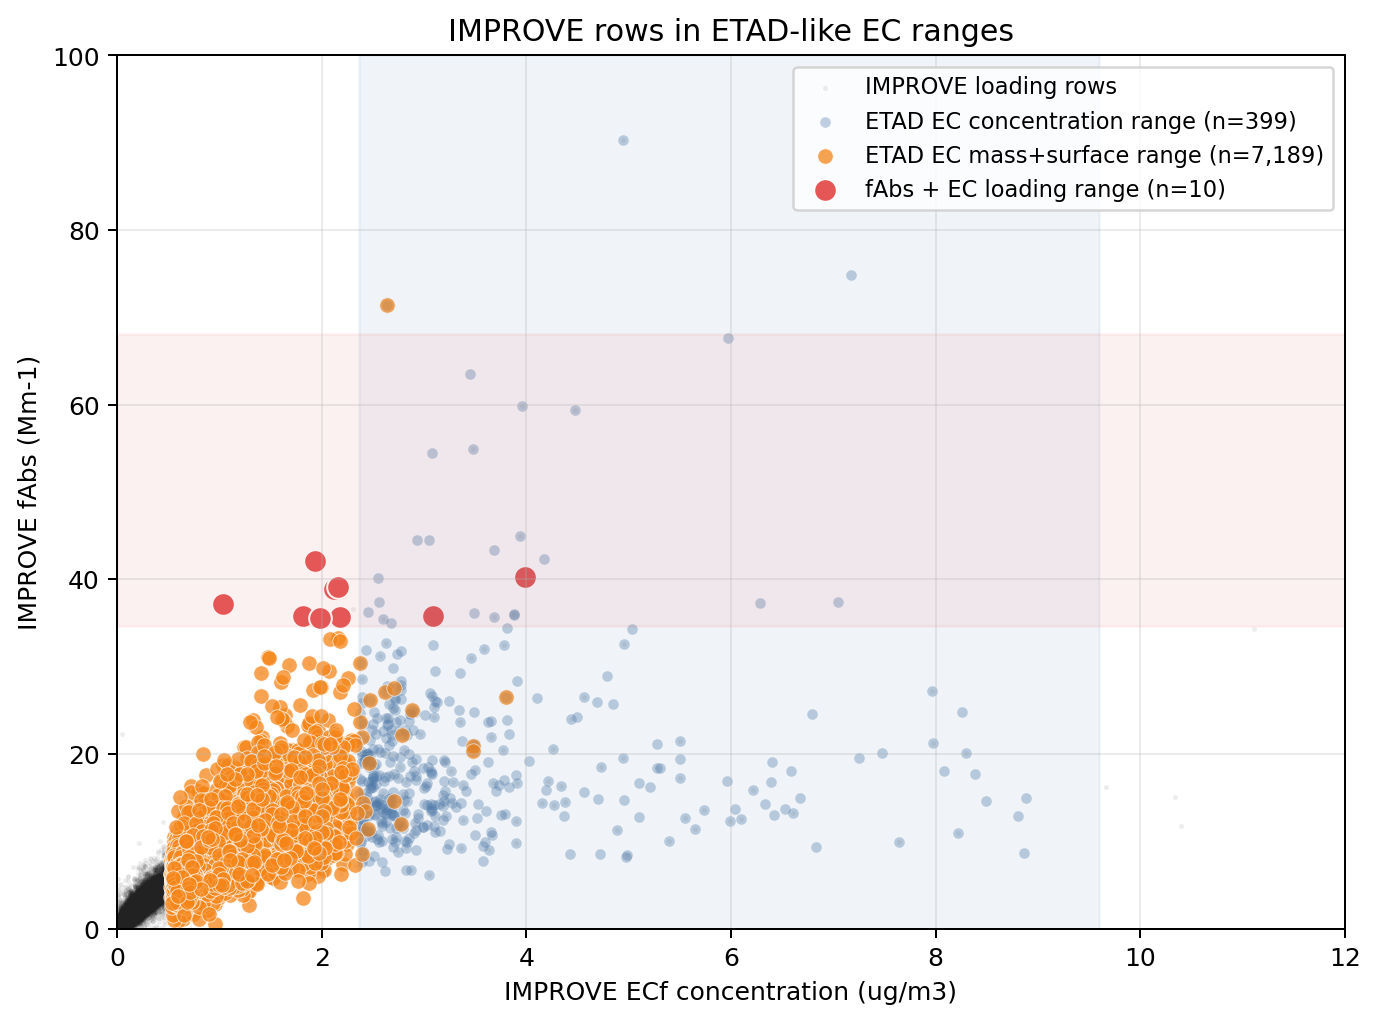

In [9]:
etad_fabs_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('fAbs_Mm-1'), 'p05'].iloc[0])
etad_fabs_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('fAbs_Mm-1'), 'p95'].iloc[0])
etad_ec_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_ug_m3'), 'p05'].iloc[0])
etad_ec_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_ug_m3'), 'p95'].iloc[0])
etad_mass_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_loading_ug_filter'), 'p05'].iloc[0])
etad_mass_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_loading_ug_filter'), 'p95'].iloc[0])
etad_surface_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_loading_ug_cm2'), 'p05'].iloc[0])
etad_surface_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_loading_ug_cm2'), 'p95'].iloc[0])

improve_loading['etad_ec_conc_p05p95_here'] = improve_loading['ECf_Val'].between(etad_ec_p05, etad_ec_p95)
improve_loading['etad_ec_mass_p05p95_here'] = improve_loading['EC_loading_ug'].between(etad_mass_p05, etad_mass_p95)
improve_loading['etad_ec_surface_p05p95_here'] = improve_loading['EC_loading_ug_cm2_primary'].between(etad_surface_p05, etad_surface_p95)
improve_loading['etad_fabs_p05p95_here'] = improve_loading['fAbs_Val'].between(etad_fabs_p05, etad_fabs_p95)
improve_loading['etad_all_ec_loading_here'] = improve_loading['etad_ec_mass_p05p95_here'] & improve_loading['etad_ec_surface_p05p95_here']
improve_loading['etad_all_axes_here'] = improve_loading['etad_fabs_p05p95_here'] & improve_loading['etad_all_ec_loading_here']

ec_range_summary = pd.DataFrame([
    {'screen': 'ETAD EC concentration p05-p95', 'n': int(improve_loading['etad_ec_conc_p05p95_here'].sum()), 'sites': improve_loading.loc[improve_loading['etad_ec_conc_p05p95_here'], 'SiteCode'].nunique()},
    {'screen': 'ETAD EC mass p05-p95', 'n': int(improve_loading['etad_ec_mass_p05p95_here'].sum()), 'sites': improve_loading.loc[improve_loading['etad_ec_mass_p05p95_here'], 'SiteCode'].nunique()},
    {'screen': 'ETAD EC surface loading p05-p95', 'n': int(improve_loading['etad_ec_surface_p05p95_here'].sum()), 'sites': improve_loading.loc[improve_loading['etad_ec_surface_p05p95_here'], 'SiteCode'].nunique()},
    {'screen': 'ETAD EC mass + surface p05-p95', 'n': int(improve_loading['etad_all_ec_loading_here'].sum()), 'sites': improve_loading.loc[improve_loading['etad_all_ec_loading_here'], 'SiteCode'].nunique()},
    {'screen': 'ETAD fAbs + EC mass + surface p05-p95', 'n': int(improve_loading['etad_all_axes_here'].sum()), 'sites': improve_loading.loc[improve_loading['etad_all_axes_here'], 'SiteCode'].nunique()},
])
ec_range_summary.to_csv(OUT / 'etad_ec_range_overlap_summary.csv', index=False)
display(ec_range_summary)

fig, ax = plt.subplots(figsize=(8.8, 6.3))
base = improve_loading.sample(min(len(improve_loading), 70000), random_state=11)
ax.scatter(base['ECf_Val'], base['fAbs_Val'], s=4, alpha=0.08, color='#222222', linewidths=0, rasterized=True, label='IMPROVE loading rows')
conc = improve_loading[improve_loading['etad_ec_conc_p05p95_here']]
ax.scatter(conc['ECf_Val'], conc['fAbs_Val'], s=18, alpha=0.35, color='#4C78A8', linewidths=0, label=f'ETAD EC concentration range (n={len(conc):,})')
all_ec = improve_loading[improve_loading['etad_all_ec_loading_here']]
ax.scatter(all_ec['ECf_Val'], all_ec['fAbs_Val'], s=38, alpha=0.75, color='#F58518', edgecolor='white', linewidth=0.35, label=f'ETAD EC mass+surface range (n={len(all_ec):,})')
all_axes = improve_loading[improve_loading['etad_all_axes_here']]
ax.scatter(all_axes['ECf_Val'], all_axes['fAbs_Val'], s=82, color='#E45756', edgecolor='white', linewidth=0.8, label=f'fAbs + EC loading range (n={len(all_axes):,})')
ax.axvspan(etad_ec_p05, etad_ec_p95, color='#4C78A8', alpha=0.08)
ax.axhspan(etad_fabs_p05, etad_fabs_p95, color='#E45756', alpha=0.08)
ax.set_xlim(0, 12)
ax.set_ylim(0, 100)
ax.set_xlabel('IMPROVE ECf concentration (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm-1)')
ax.set_title('IMPROVE rows in ETAD-like EC ranges')
ax.legend(loc='upper right', frameon=True)
caption = 'Highlights IMPROVE rows with ETAD-like EC concentration and EC loading, plus the much smaller subset that also has ETAD-like fAbs.'
path = savefig(fig, 'fig07_etad_ec_range_overlap_highlight.png', caption)
Image(filename=str(path))

## 6. High-fAbs IMPROVE Samples: What is Their EC Loading?

This answers the direct question: for the high-fAbs IMPROVE tail, what EC mass loading do those samples carry?

,SiteCode,SiteName,State,Date,fAbs_Val,ECf_Val,EC_loading_ug,EC_loading_ug_cm2_primary,OC_EC,FE_EC,SOIL_EC,rt_available
315989,NOGA1,Nogales,AZ,2024-01-01,310.95,6.88931,70.908632,20.259609,7.365276,0.094512,2.604426,True
293723,LAVO1,Lassen Volcanic NP,CA,2023-11-02,184.22,9.27957,104.703685,29.915339,46.138903,0.030928,0.189604,True
325341,PHOE1,Phoenix,AZ,2022-12-25,90.26,4.94577,107.098770,30.599649,2.432996,0.057150,0.578986,True
293801,LAVO1,Lassen Volcanic NP,CA,2024-07-26,74.89,7.17680,117.664520,33.618434,6.081825,0.013070,0.158536,True
376563,WIMO1,Wichita Mountains,OK,2024-10-27,71.38,2.63763,41.507129,11.859180,14.849535,0.029068,0.596691,True
326251,PHOE5,Phoenix Colocated Sampler,AZ,2021-01-01,67.58,5.97482,145.416693,41.547626,4.843379,0.064405,0.836678,True
325176,PHOE1,Phoenix,AZ,2021-01-01,63.45,3.45283,86.688131,24.768037,8.382701,0.112847,1.530828,True
315406,NOGA1,Nogales,AZ,2017-12-24,62.93,12.74510,365.361233,104.388924,1.948490,0.032372,0.528724,True
268067,FRES1,Fresno,CA,2025-01-01,59.85,3.95789,74.297160,21.227760,2.536996,0.040292,0.231532,True
364619,TRIN1,Trinity,CA,2017-09-04,59.34,4.47185,113.382862,32.395104,19.887183,0.049995,0.534973,True


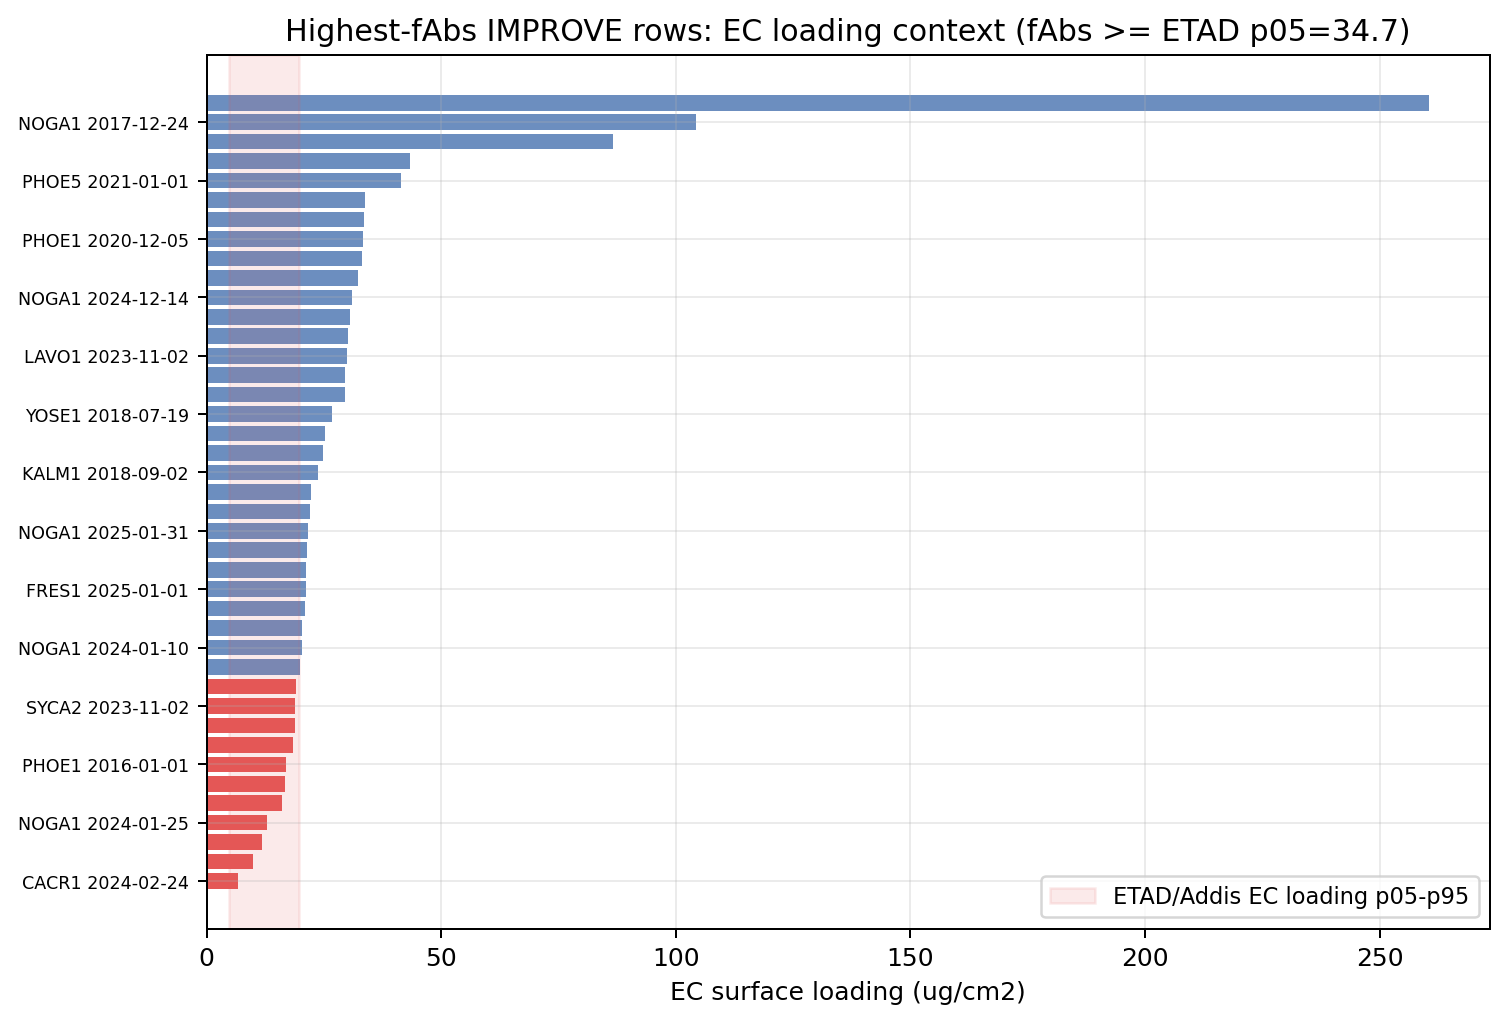

In [10]:
etad_fabs_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('fAbs_Mm-1'), 'p05'].iloc[0])
etad_fabs_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('fAbs_Mm-1'), 'p95'].iloc[0])
etad_loading_p05 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_surface_loading_ug_cm2'), 'p05'].iloc[0]) if 'EC_surface_loading_ug_cm2' in etad_bounds['metric'].values else float(spartan_loading.loc[spartan_loading['Site'].eq('ETAD'), 'EC_loading_ug_cm2_p05'].iloc[0])
etad_loading_p95 = float(etad_bounds.loc[etad_bounds['metric'].eq('EC_surface_loading_ug_cm2'), 'p95'].iloc[0]) if 'EC_surface_loading_ug_cm2' in etad_bounds['metric'].values else float(spartan_loading.loc[spartan_loading['Site'].eq('ETAD'), 'EC_loading_ug_cm2_p95'].iloc[0])

high_fabs = improve_loading[improve_loading['fAbs_Val'] >= etad_fabs_p05].copy()
high_fabs = high_fabs.sort_values('fAbs_Val', ascending=False)
cols = ['SiteCode', 'SiteName', 'State', 'Date', 'fAbs_Val', 'ECf_Val', 'EC_loading_ug', 'EC_loading_ug_cm2_primary', 'OC_EC', 'FE_EC', 'SOIL_EC', 'rt_available']
high_fabs_table = high_fabs[cols].head(40).copy()
high_fabs_table.to_csv(OUT / 'high_fabs_improve_top40_loading_table.csv', index=False)
display(high_fabs_table.head(15))

fig, ax = plt.subplots(figsize=(9.2, 6.3))
plot = high_fabs.head(60).sort_values('EC_loading_ug_cm2_primary')
colors = np.where(plot['EC_loading_ug_cm2_primary'].between(etad_loading_p05, etad_loading_p95), '#E45756', '#6C8EBF')
labels = plot['SiteCode'] + ' ' + plot['Date'].dt.strftime('%Y-%m-%d')
ax.barh(np.arange(len(plot)), plot['EC_loading_ug_cm2_primary'], color=colors)
ax.axvspan(etad_loading_p05, etad_loading_p95, color='#E45756', alpha=0.12, label='ETAD/Addis EC loading p05-p95')
ax.set_yticks(np.arange(len(plot))[::3], labels.iloc[::3], fontsize=7)
ax.set_xlabel('EC surface loading (ug/cm2)')
ax.set_title(f'Highest-fAbs IMPROVE rows: EC loading context (fAbs >= ETAD p05={etad_fabs_p05:.1f})')
ax.legend(loc='lower right', frameon=True)
caption = 'Ranked high-fAbs IMPROVE candidates showing whether their EC loading falls in the Addis/ETAD loading range.'
path = savefig(fig, 'fig07_high_fabs_improve_ec_loading_ranked.png', caption)
Image(filename=str(path))

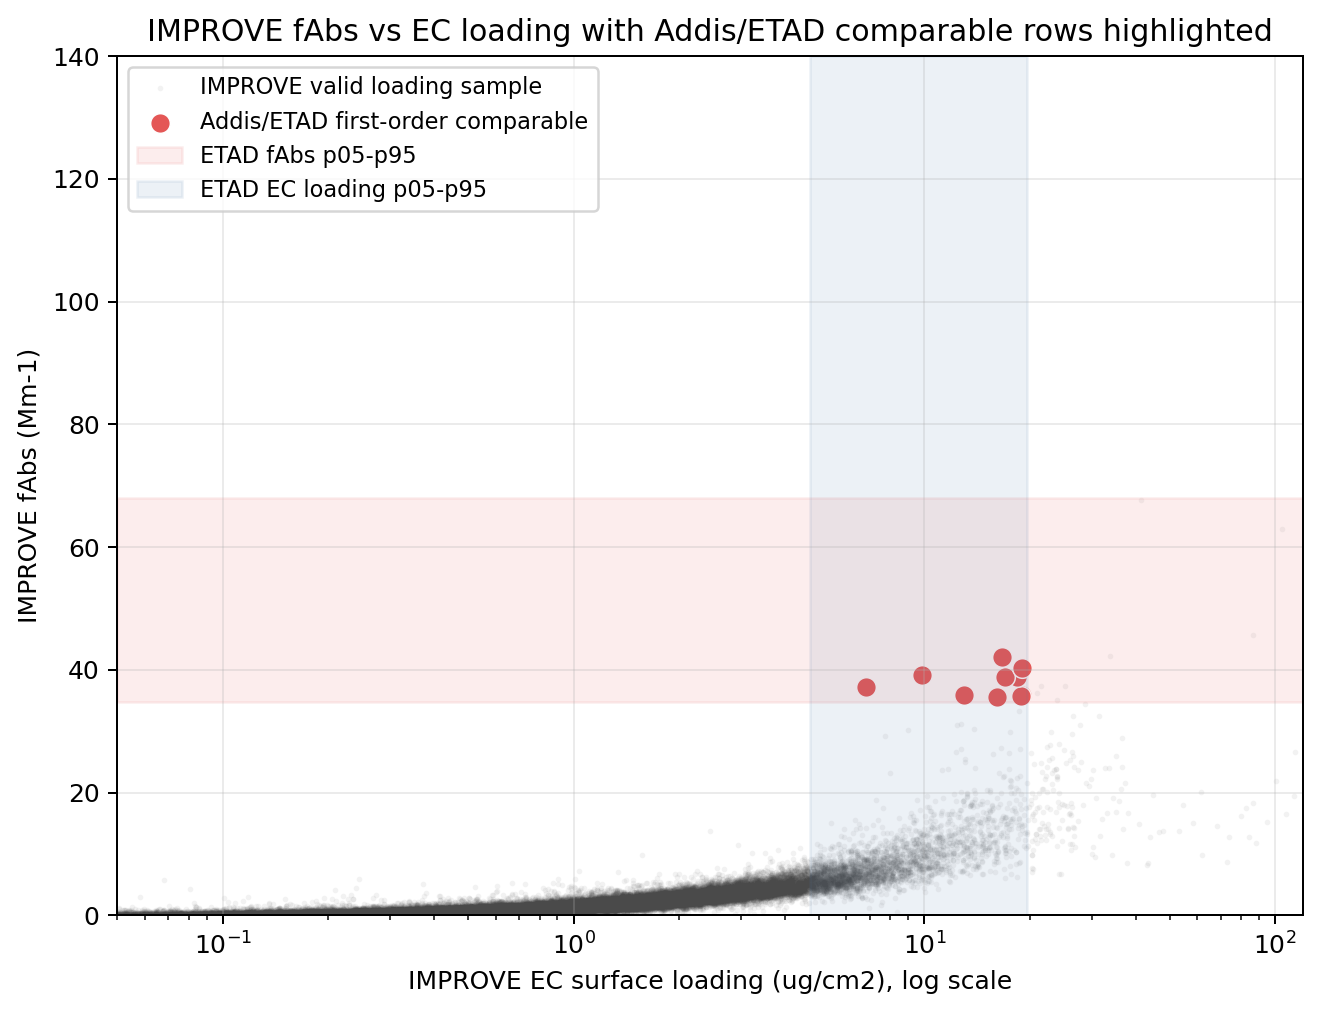

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
base = improve_loading.sample(min(len(improve_loading), 60000), random_state=7)
ax.scatter(base['EC_loading_ug_cm2_primary'], base['fAbs_Val'], s=5, alpha=0.07, color='#4A4A4A', linewidths=0, rasterized=True, label='IMPROVE valid loading sample')
ax.scatter(comparable['EC_loading_ug_cm2_primary'], comparable['fAbs_Val'], s=62, color='#E45756', edgecolor='white', linewidth=0.6, label='Addis/ETAD first-order comparable')
ax.axhspan(etad_fabs_p05, etad_fabs_p95, color='#E45756', alpha=0.10, label='ETAD fAbs p05-p95')
ax.axvspan(etad_loading_p05, etad_loading_p95, color='#4C78A8', alpha=0.10, label='ETAD EC loading p05-p95')
ax.set_xscale('log')
ax.set_xlim(0.05, max(120, improve_loading['EC_loading_ug_cm2_primary'].quantile(0.999)))
ax.set_ylim(0, 140)
ax.set_xlabel('IMPROVE EC surface loading (ug/cm2), log scale')
ax.set_ylabel('IMPROVE fAbs (Mm-1)')
ax.set_title('IMPROVE fAbs vs EC loading with Addis/ETAD comparable rows highlighted')
ax.legend(loc='upper left', frameon=True)
caption = 'Two-axis loading-space view: high fAbs alone is not equivalent to Addis/ETAD comparability.'
path = savefig(fig, 'fig08_fabs_vs_loading_comparable_highlight.png', caption)
Image(filename=str(path))

## 7. Regression Sensitivity: Baseline vs Comparable Regimes

The bounded groups are small and selected on the axes under study. This plot is for meeting framing, not for claiming a final MAC correction.

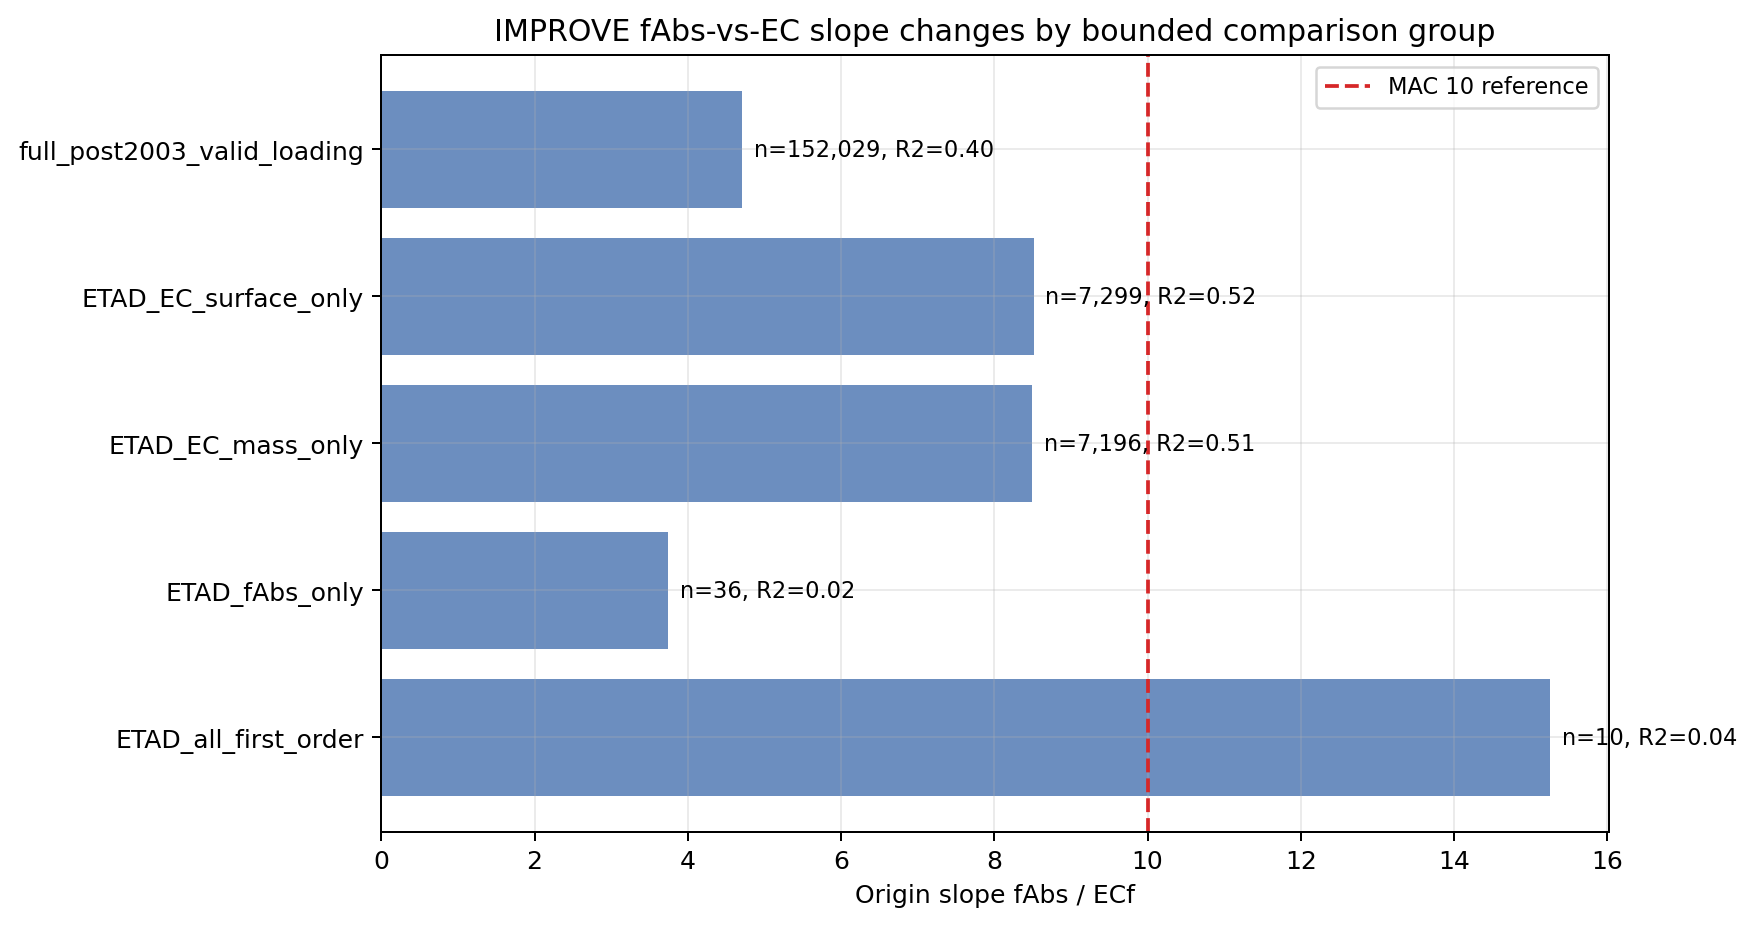

In [12]:
fig, ax = plt.subplots(figsize=(8.8, 5.6))
bf = bounded_fits.copy()
bf = bf.sort_values('n', ascending=False)
y = np.arange(len(bf))
ax.barh(y, bf['origin_slope'], color='#6C8EBF')
for i, row in bf.iterrows():
    ax.text(row['origin_slope'] + 0.15, y[list(bf.index).index(i)], f"n={int(row['n']):,}, R2={row['r2']:.2f}", va='center', fontsize=9)
ax.axvline(10, color='#D62728', ls='--', lw=1.5, label='MAC 10 reference')
ax.set_yticks(y, bf['group'])
ax.invert_yaxis()
ax.set_xlabel('Origin slope fAbs / ECf')
ax.set_title('IMPROVE fAbs-vs-EC slope changes by bounded comparison group')
ax.legend(frameon=True)
caption = 'Regression sensitivity across full post-2003 loading rows and Addis/ETAD-bounded groups.'
path = savefig(fig, 'fig09_bounded_group_origin_slopes.png', caption)
bf.to_csv(OUT / 'bounded_group_fits_for_meeting.csv', index=False)
Image(filename=str(path))

## 8. FED Laser R/T Diagnostic Space

This is a diagnostic analog only. It should be shown with the caveat that FED does not expose raw Warren Figure 2 HIPS sphere/plate R/T, blanks, lot IDs, or blank-line fits.

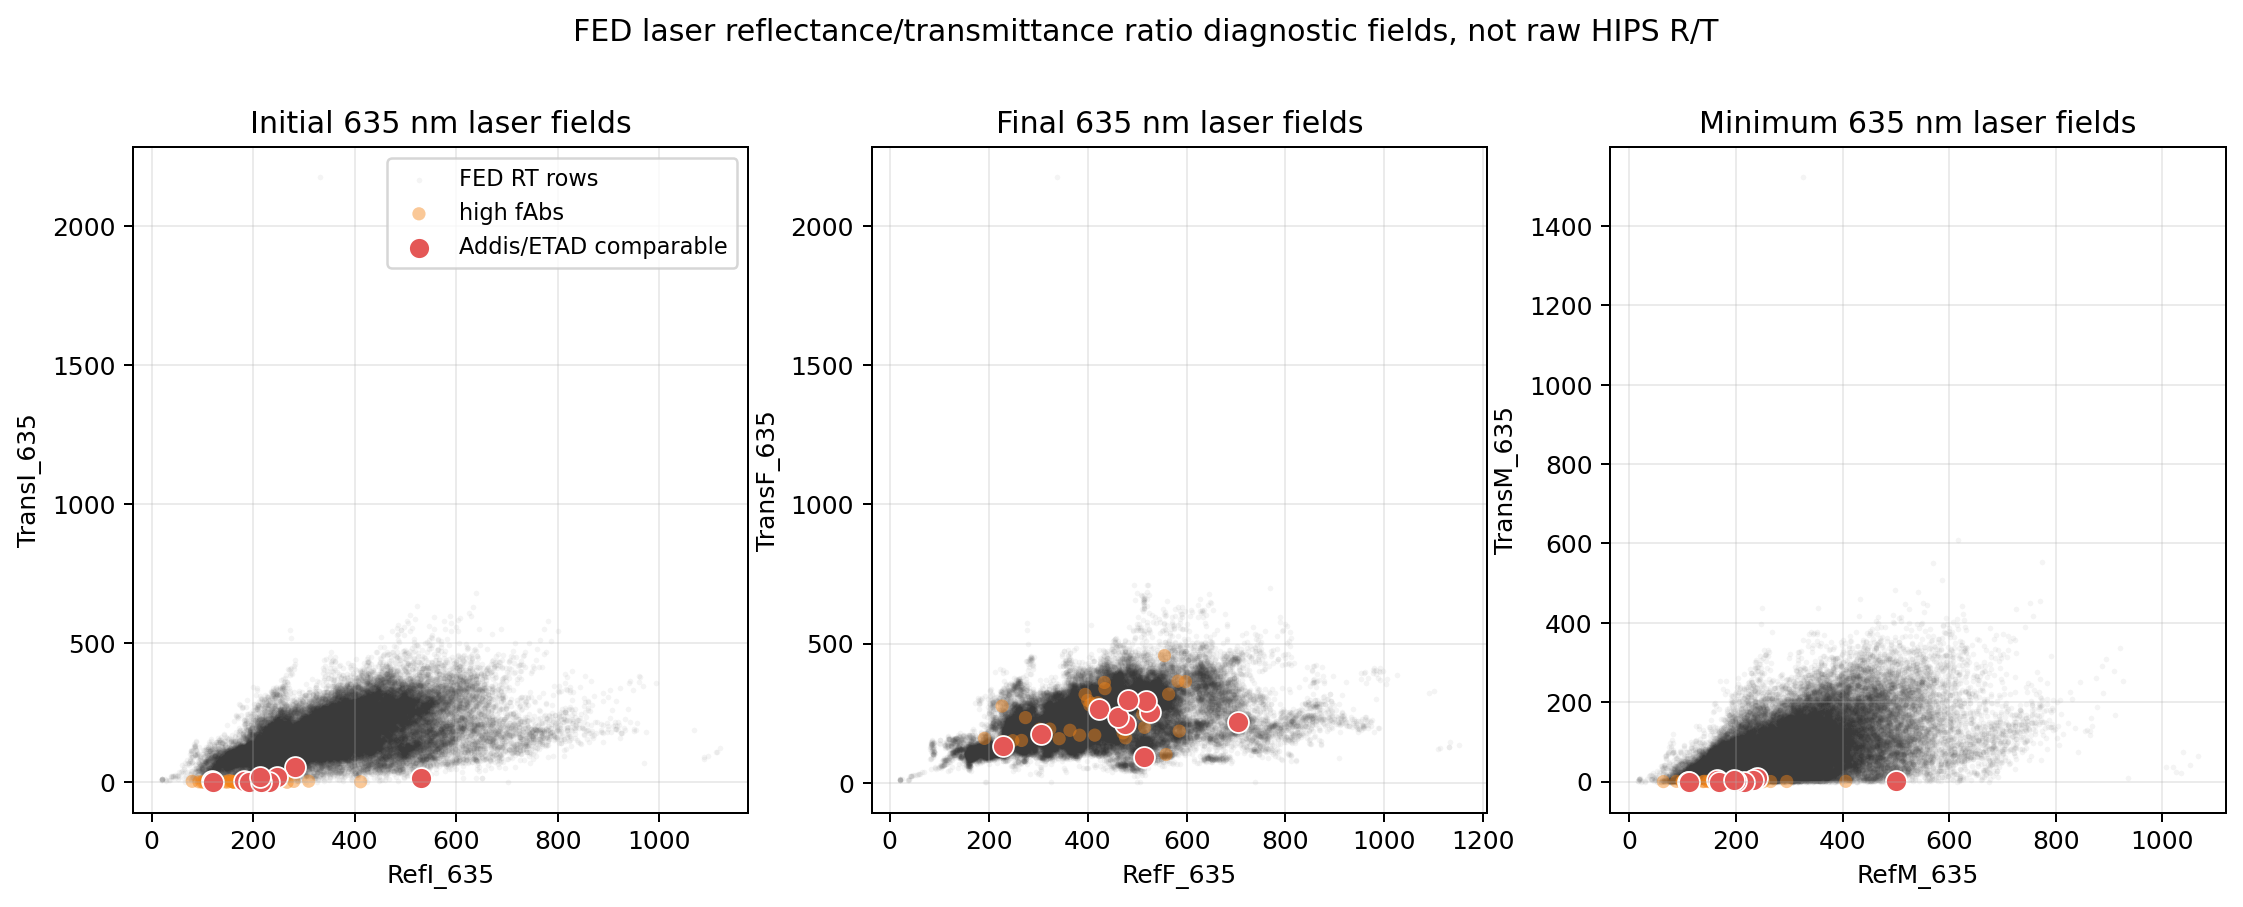

In [13]:
key_cols = ['SiteCode', 'Date', 'POC', 'AuxID']
comp_keys = set(comparable[key_cols].astype(str).agg('|'.join, axis=1))
rt = improve_loading[improve_loading['rt_available'].fillna(False)].copy()
rt['key'] = rt[key_cols].astype(str).agg('|'.join, axis=1)
rt['is_comparable'] = rt['key'].isin(comp_keys)
rt['high_fabs_ge_etad_p05'] = rt['fAbs_Val'] >= etad_fabs_p05

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=False, sharey=False)
pairs = [
    ('initial', 'RefI_635_Val', 'TransI_635_Val'),
    ('final', 'RefF_635_Val', 'TransF_635_Val'),
    ('minimum', 'RefM_635_Val', 'TransM_635_Val'),
]
for ax, (label, rx, tx) in zip(axes, pairs):
    d = rt[[rx, tx, 'is_comparable', 'high_fabs_ge_etad_p05']].dropna()
    bg = d.sample(min(len(d), 50000), random_state=7)
    ax.scatter(bg[rx], bg[tx], s=5, alpha=0.05, color='#3A3A3A', linewidths=0, rasterized=True, label='FED RT rows')
    hf = d[d['high_fabs_ge_etad_p05']]
    ax.scatter(hf[rx], hf[tx], s=28, alpha=0.45, color='#F58518', edgecolor='none', label='high fAbs')
    comp = d[d['is_comparable']]
    ax.scatter(comp[rx], comp[tx], s=70, color='#E45756', edgecolor='white', linewidth=0.7, label='Addis/ETAD comparable')
    ax.set_title(f'{label.title()} 635 nm laser fields')
    ax.set_xlabel(rx.replace('_Val', ''))
    ax.set_ylabel(tx.replace('_Val', ''))
axes[0].legend(loc='best', frameon=True)
fig.suptitle('FED laser reflectance/transmittance ratio diagnostic fields, not raw HIPS R/T', y=1.03)
caption = 'FED laser R/T diagnostic space with high-fAbs and Addis/ETAD comparable rows highlighted; not a Warren Figure 2 reproduction.'
path = savefig(fig, 'fig10_fed_laser_rt_diagnostic_space.png', caption)
Image(filename=str(path))

## 9. Lower-Priority Filter Lot Context

Ann suggested keeping MTL filter lot lower priority. This figure is included only to make the existing SPARTAN lot-count situation visible before asking Warren how much lot matters for R/T overlays.

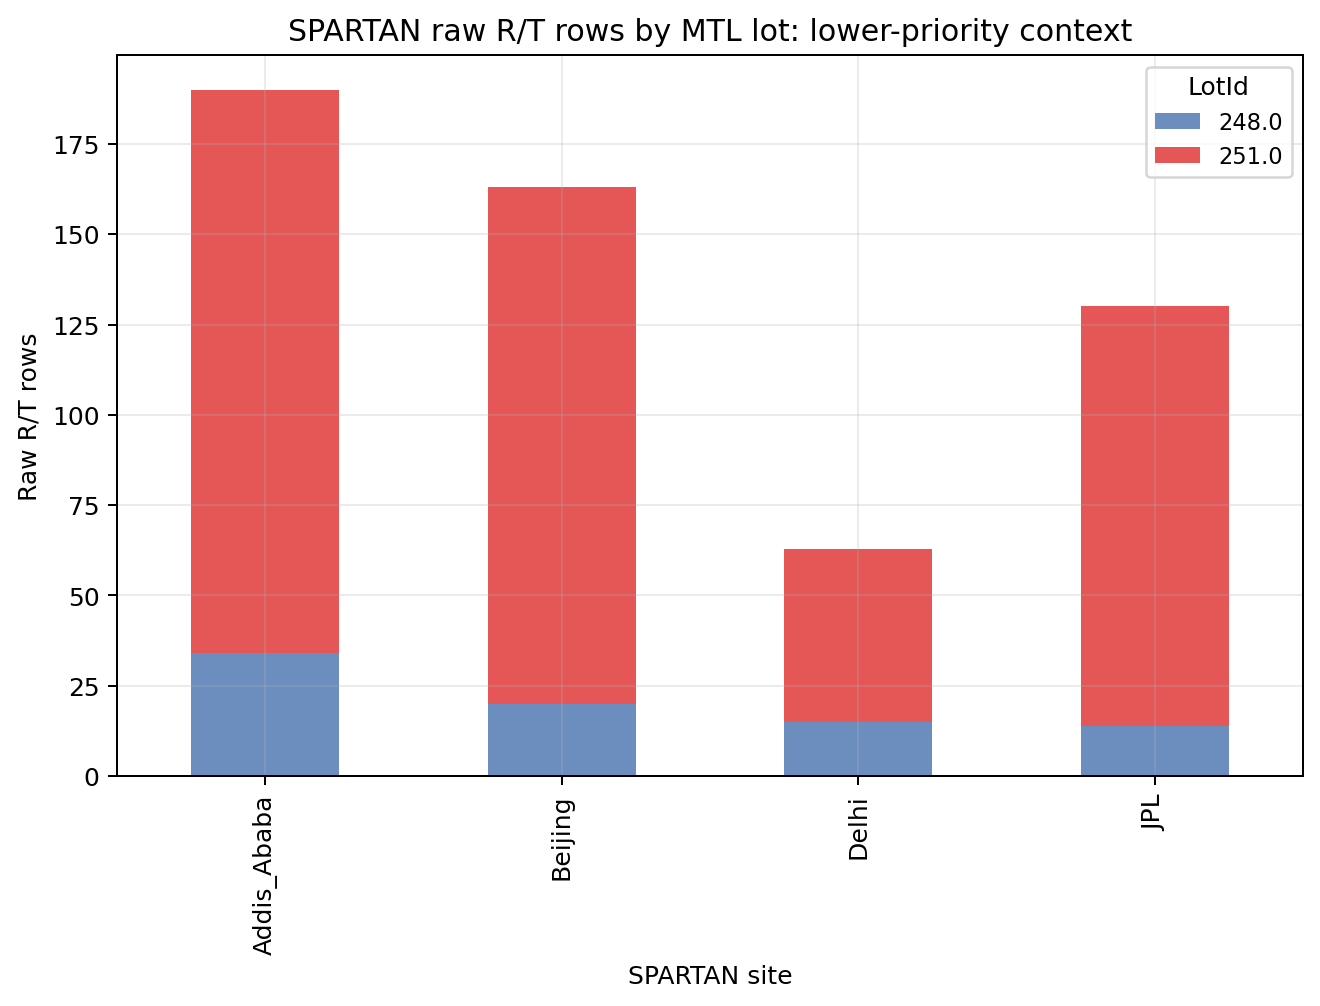

In [14]:
lot_counts = read_csv(RT_PROXY_OUT / 'spartan_raw_rt_counts_by_site_filtertype_lot.csv')
fig, ax = plt.subplots(figsize=(8.5, 5.2))
pivot = lot_counts.pivot_table(index='SiteName', columns='LotId', values='n', aggfunc='sum', fill_value=0).sort_index()
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#6C8EBF', '#E45756', '#72B7B2', '#F58518'][:len(pivot.columns)])
ax.set_xlabel('SPARTAN site')
ax.set_ylabel('Raw R/T rows')
ax.set_title('SPARTAN raw R/T rows by MTL lot: lower-priority context')
ax.legend(title='LotId', frameon=True)
caption = 'SPARTAN raw R/T row counts by site and MTL lot; lot interpretation still requires Warren/Alex/operations input.'
path = savefig(fig, 'fig11_spartan_rt_lot_counts_lower_priority.png', caption)
pivot.to_csv(OUT / 'spartan_rt_lot_counts_pivot.csv')
Image(filename=str(path))

## 10. Existing Four-Site SPARTAN Figure

The four-site SPARTAN cross-site result was already generated in `warren_cena_improve_prep_analysis`. The figure is copied into this output folder so the full May graph packet is self-contained.

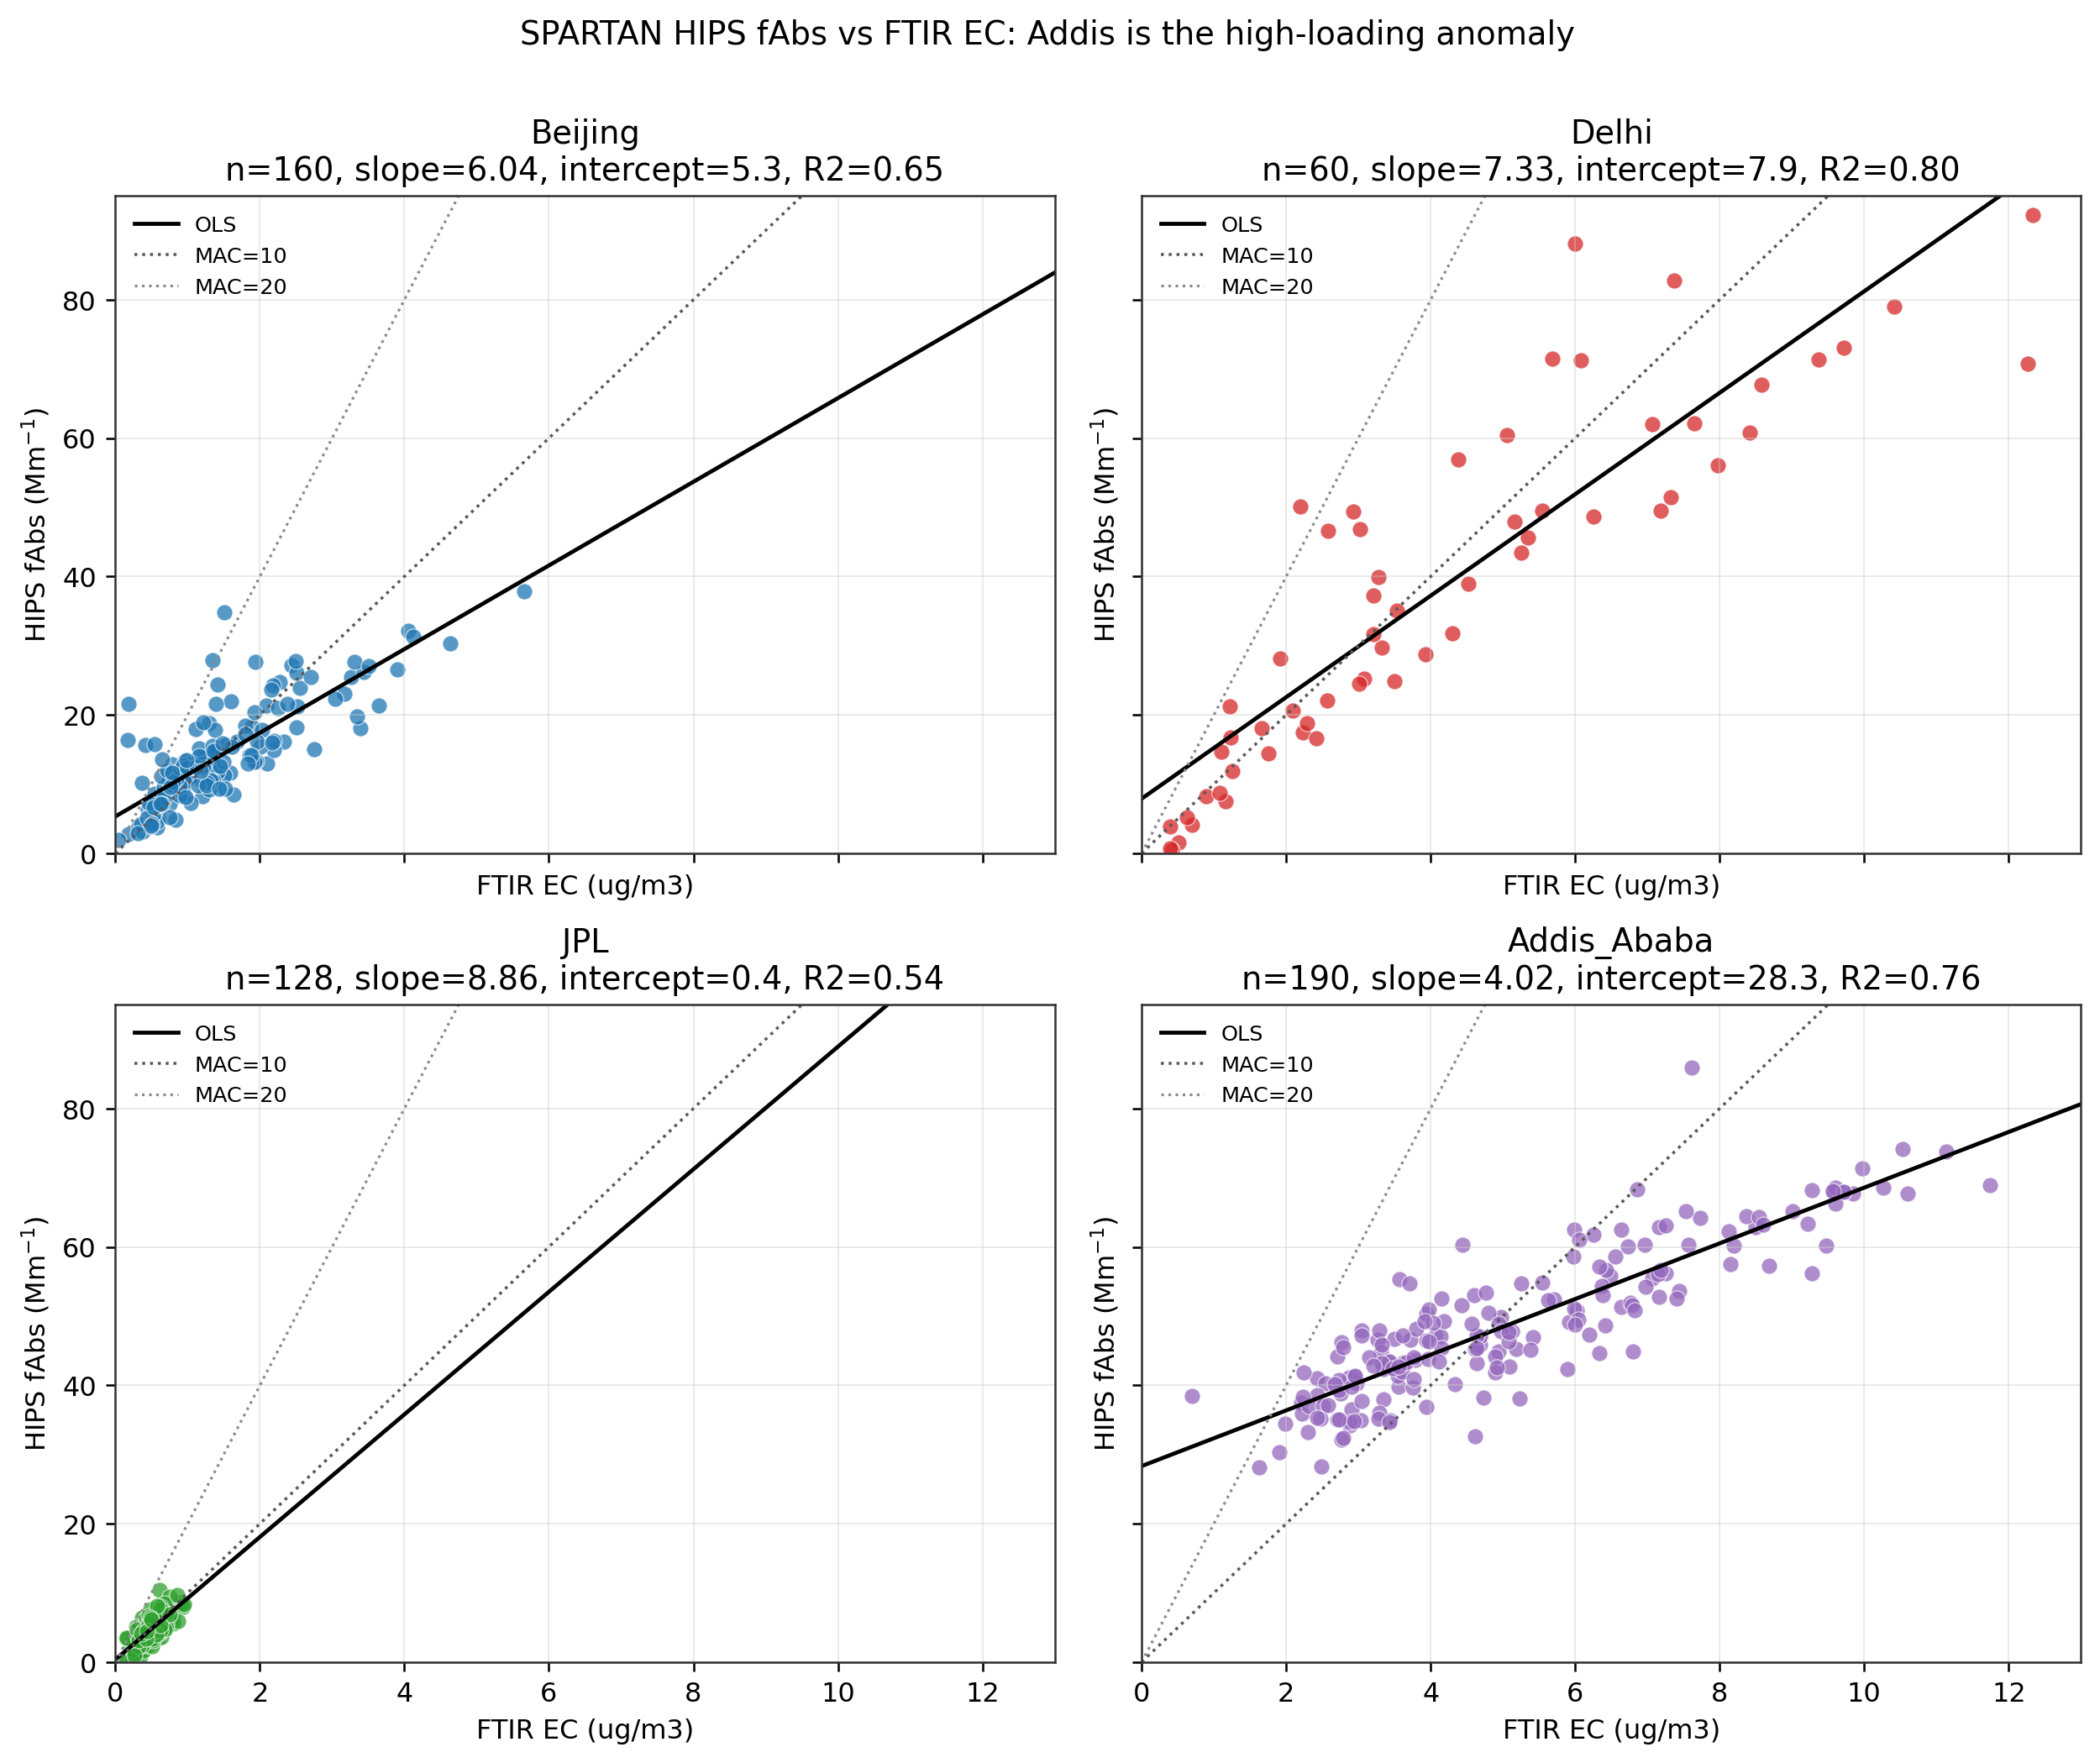

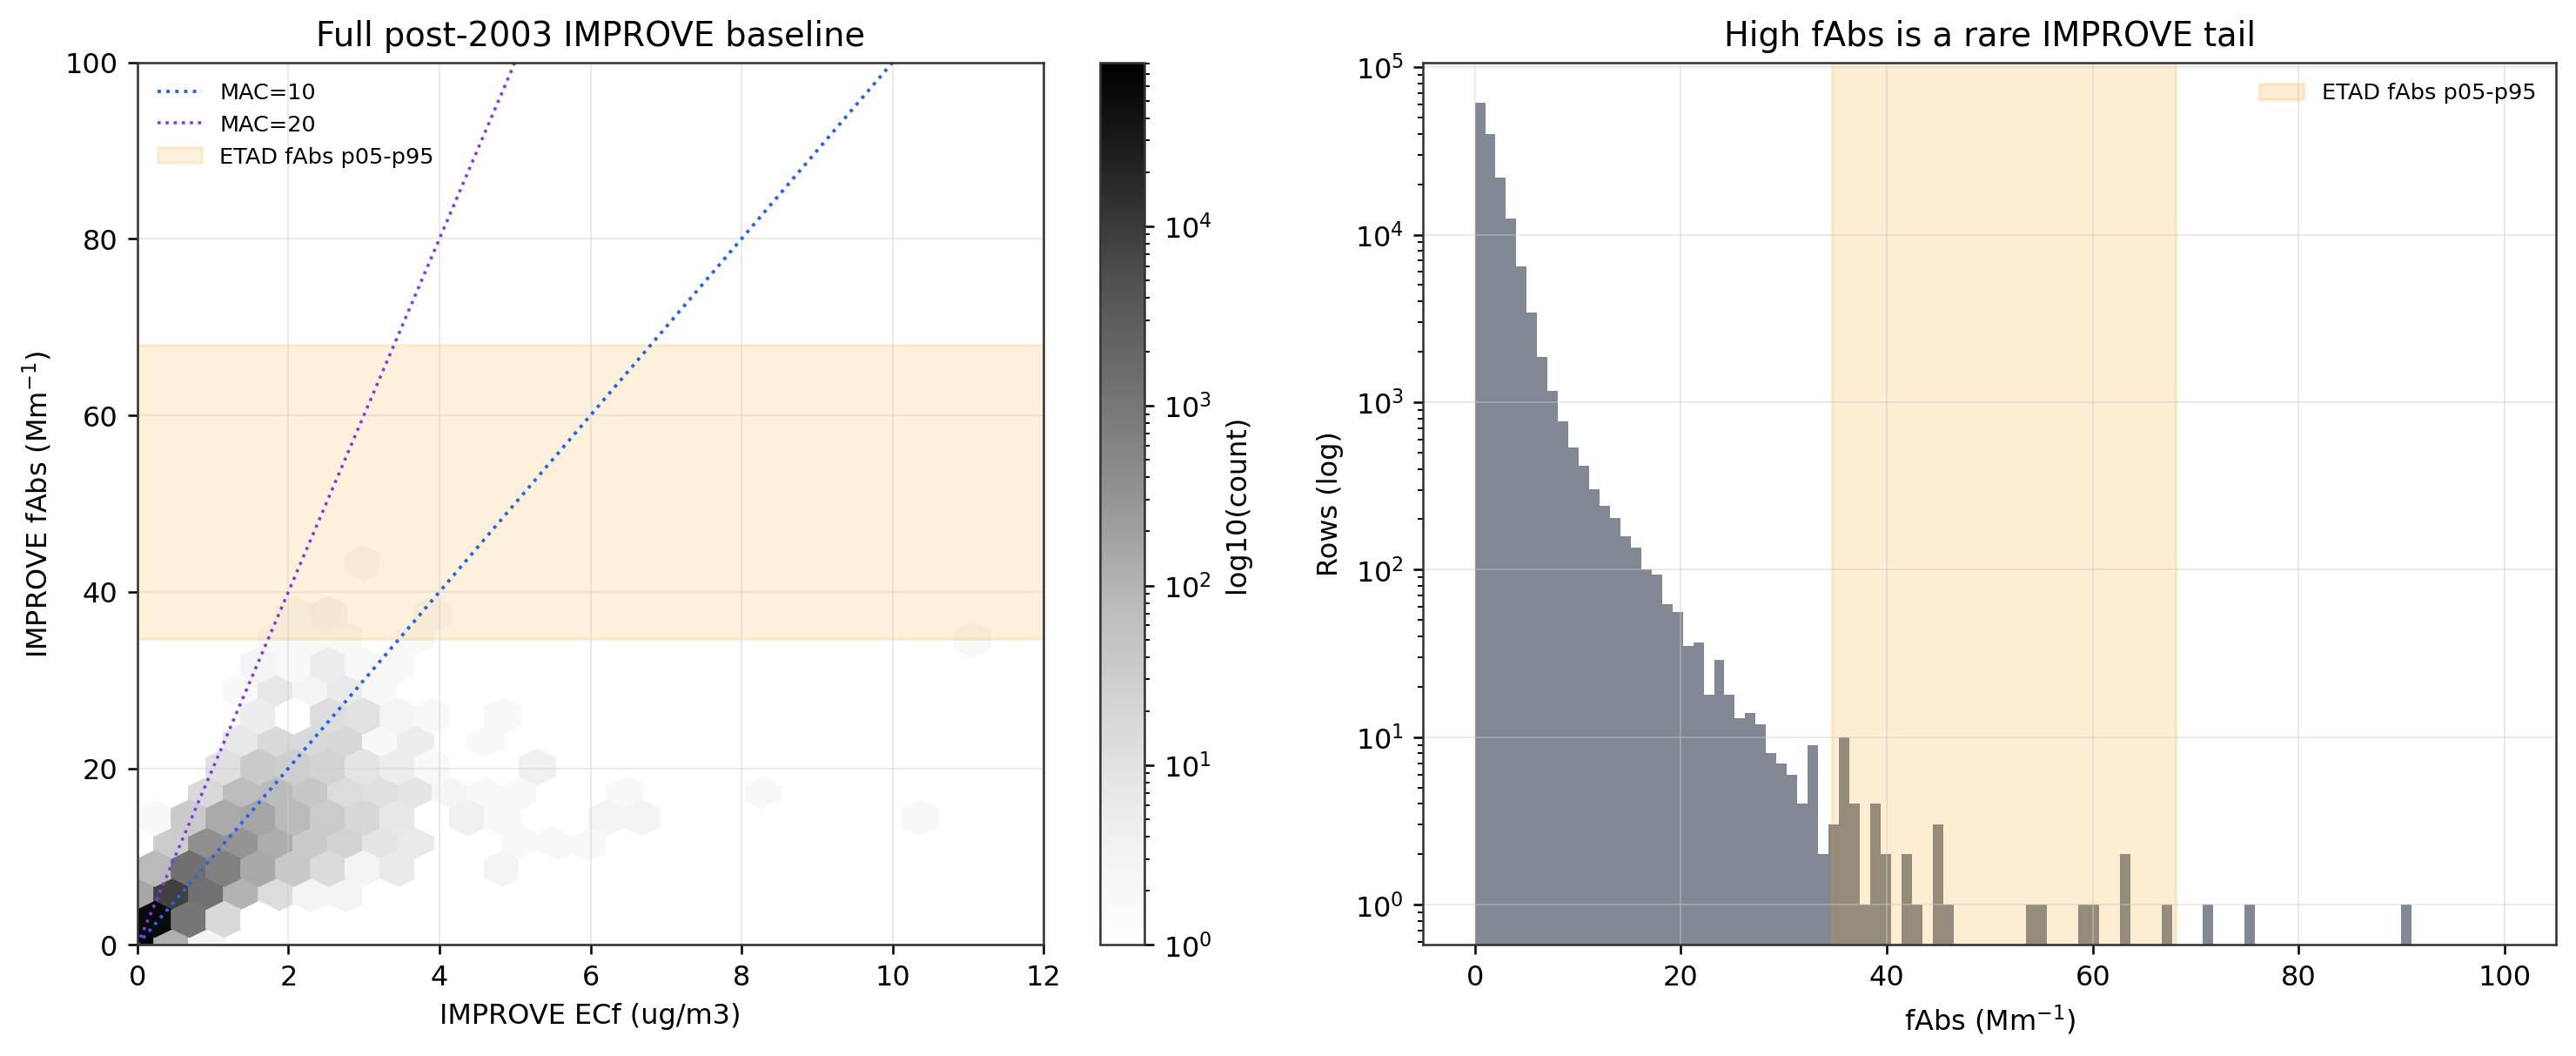

In [15]:
source_figs = [
    (MAY_PREP_OUT / 'spartan_four_site_hips_fabs_vs_ec.png', 'fig12_spartan_four_site_hips_fabs_vs_ec.png', 'SPARTAN four-site HIPS fAbs vs FTIR EC cross-plots.'),
    (MAY_PREP_OUT / 'improve_post2003_baseline_before_screening.png', 'fig13_existing_improve_post2003_baseline_before_screening.png', 'Existing post-2003 baseline before screening from Warren/Cena prep notebook.'),
]
for src, name, caption in source_figs:
    if src.exists():
        dst = OUT / name
        shutil.copy2(src, dst)
        FIGURES.append({'figure': name, 'path': str(dst.relative_to(ROOT)), 'caption': caption})
        display(Image(filename=str(dst)))
    else:
        print(f'Missing existing figure: {src.relative_to(ROOT)}')

## 11. Figure Manifest and Readout

Use this manifest to build the May recap or slide deck. The key interpretation is that Addis/ETAD-like fAbs and loading overlap exists in IMPROVE, but it is rare and not enough by itself to prove a final MAC correction. R/T overlays need careful labeling because FED exposes laser R/T ratio fields, not raw Warren Figure 2 HIPS R/T signals.

In [16]:
manifest = pd.DataFrame(FIGURES)
manifest.to_csv(OUT / 'figure_manifest.csv', index=False)
display(manifest)

readout = pd.DataFrame([
    {'topic': 'IMPROVE baseline', 'message': 'Post-2003 fAbs vs EC can be shown as raw points and density without arbitrary fAbs thresholding.'},
    {'topic': 'Mass loading', 'message': 'IMPROVE EC concentrations have been converted to EC mass/surface loading; loading rows are a subset where flow and duration are available.'},
    {'topic': 'Addis/ETAD comparability', 'message': 'The combined fAbs + EC loading overlap is real but rare, so it should be framed as a special regime rather than the central IMPROVE population.'},
    {'topic': 'High-fAbs tail', 'message': 'High-fAbs IMPROVE samples have a wide EC loading range; the candidate table identifies which ones are actually loading-comparable to Addis/ETAD.'},
    {'topic': 'FED R/T', 'message': 'Label as FED laser R/T ratio fields; exact Warren Figure 2 reproduction requires direct raw HIPS/blanks/lot/calibration metadata.'},
    {'topic': 'MTL lots', 'message': 'Keep lower priority as Ann suggested; ask Warren how much lot matters before over-investing in lot-specific overlays.'},
])
readout.to_csv(OUT / 'analysis_readout.csv', index=False)
display(readout)

,figure,path,caption
0,fig01_improve_post2003_raw_fabs_vs_ec.png,research/improve_hips_offset/output/improve_sp...,Raw post-2003 IMPROVE fAbs vs ECf baseline wit...
1,fig02_improve_post2003_density_fabs_vs_ec.png,research/improve_hips_offset/output/improve_sp...,Density view of the same unfiltered post-2003 ...
2,fig03_improve_loading_vs_spartan_ranges.png,research/improve_hips_offset/output/improve_sp...,Filter-loading comparison: IMPROVE concentrati...
3,fig04_loading_range_summary.png,research/improve_hips_offset/output/improve_sp...,"Range plot summarizing p05-p95, p25-p75, and m..."
4,fig05_axis_by_axis_screening_waterfall.png,research/improve_hips_offset/output/improve_sp...,Sequential screen showing how rare Addis/ETAD-...
5,fig06_axis_overlap_counts.png,research/improve_hips_offset/output/improve_sp...,"Independent axis overlap counts: fAbs, EC conc..."
6,fig07_etad_ec_range_overlap_highlight.png,research/improve_hips_offset/output/improve_sp...,Highlights IMPROVE rows with ETAD-like EC conc...
7,fig07_high_fabs_improve_ec_loading_ranked.png,research/improve_hips_offset/output/improve_sp...,Ranked high-fAbs IMPROVE candidates showing wh...
8,fig08_fabs_vs_loading_comparable_highlight.png,research/improve_hips_offset/output/improve_sp...,Two-axis loading-space view: high fAbs alone i...
9,fig09_bounded_group_origin_slopes.png,research/improve_hips_offset/output/improve_sp...,Regression sensitivity across full post-2003 l...


,topic,message
0,IMPROVE baseline,Post-2003 fAbs vs EC can be shown as raw point...
1,Mass loading,IMPROVE EC concentrations have been converted ...
2,Addis/ETAD comparability,The combined fAbs + EC loading overlap is real...
3,High-fAbs tail,High-fAbs IMPROVE samples have a wide EC loadi...
4,FED R/T,Label as FED laser R/T ratio fields; exact War...
5,MTL lots,Keep lower priority as Ann suggested; ask Warr...
